# List of galaxies in the localisation volume

Credit: Nikolai Pankov

In [95]:
from astroquery.vizier import Vizier
from astropy.table import Table, vstack as vstack_table, hstack as hstack_table
from astropy.coordinates import SkyCoord
from astropy import units as u
from collections import defaultdict
import joblib
import numpy as np
import urllib
import lmfit
from matplotlib import pyplot as plt
import bottleneck as bn
from astropy.cosmology import FlatLambdaCDM
import pandas as pd
import gc
from glob import glob
from util.duplicate import remove_duplicates_sdss
from util.catalogs import load_sdss, load_gaia, load_catwise, load_gladep, load_ned_lvs, load_desi_south
from halo import Halo
from astropy.table import vstack

In [2]:
H0 = 67.4 * u.km / u.s / u.Mpc
Omega0 = 0.315
cosmos = FlatLambdaCDM(H0=H0, Om0=Omega0)

# BSA source localization

In [3]:
center = SkyCoord("16h29m49s", "13d21m")
ra_error = 45 / 60 * u.deg
dec_error = 25 * u.arcmin

In [4]:
ra_error.to("arcmin")

<Quantity 45. arcmin>

In [5]:
dec_error

<Quantity 25. arcmin>

# Total Area

In [6]:
localization_area = (2**2 *ra_error * dec_error).to(u.deg ** 2)
localization_area

<Quantity 1.25 deg2>

# Distance bounds (from paper: https://arxiv.org/pdf/2001.01761)
(all errors given at 90% confidence level)

In [7]:
dist_mean = 159 * u.Mpc
dist_nerr = 71 * u.Mpc   # 90% CI lower bound: 159 - 71 = 88 Mpc
dist_perr = 69 * u.Mpc   # 90% CI upper bound: 159 + 69 = 228 Mpc


# Loading catalogs

In [8]:
sdss_with_duplicates, sdss_path = load_sdss(center=center, width=2*ra_error, height=2*dec_error)

In [9]:
sdss = remove_duplicates_sdss(sdss_with_duplicates)

Grouping duplicated sources ...
Groups of duplicated sources were created.
Stacking groups in a single table ...


Done


In [84]:
print(f"Unique objIDs after dedup: {len(np.unique(sdss['objID']))}")
print(f"Total rows after dedup: {len(sdss)}")

Unique objIDs after dedup: 54935
Total rows after dedup: 54935


In [10]:
sdss_with_duplicates

objID,RA_ICRS,DE_ICRS,mode,class,clean,e_RA_ICRS,e_DE_ICRS,umag,gmag,rmag,imag,zmag,e_umag,e_gmag,e_rmag,e_imag,e_zmag,zsp,e_zsp,f_zsp,zph,e_zph,<zph>,Q,SDSS16,Sp-ID,MJD
,deg,deg,,,,arcsec,arcsec,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,,,,,,,,,,d
int64,float64,float64,uint8,uint8,uint8,float64,float64,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,int16,float32,float32,float32,uint8,bytes24,bytes16,float64
1237665548904170401,247.842212,12.933275,1,6,1,0.079,0.075,23.878,23.036,22.260,22.103,22.084,0.990,0.211,0.134,0.178,0.568,--,--,--,--,--,--,3,SDSS J163122.13+125559.7,--,53169.3307
1237665548904171051,247.850549,12.940121,1,6,0,0.109,0.091,25.070,25.606,23.698,21.623,20.647,1.149,0.654,0.451,0.123,0.202,--,--,--,--,--,--,3,SDSS J163124.13+125624.4,--,53169.3307
1237668337937483088,247.842213,12.933198,2,3,0,0.104,0.144,25.517,23.296,22.144,21.794,21.985,0.833,0.235,0.145,0.169,0.648,--,--,--,--,--,--,3,SDSS J163122.13+125559.5,--,53502.4350
1237668337937483107,247.856615,12.935218,4,6,0,0.115,0.135,25.280,23.777,22.692,22.494,22.009,0.761,0.281,0.194,0.254,0.540,--,--,--,--,--,--,3,SDSS J163125.58+125606.7,--,53502.4350
1237668337937483299,247.850528,12.940104,2,6,0,0.090,0.078,24.691,23.915,23.861,21.495,20.714,0.943,0.312,0.480,0.107,0.201,--,--,--,--,--,--,3,SDSS J163124.12+125624.3,--,53502.4350
1237665548367037225,247.143225,12.933879,2,3,0,0.104,0.087,22.400,21.720,21.363,21.233,21.069,0.429,0.090,0.085,0.114,0.370,--,--,--,--,--,--,3,SDSS J162834.37+125601.9,--,53169.3290
1237665548367037240,247.149572,12.934443,2,6,0,0.038,0.039,25.080,22.372,21.069,20.084,19.548,1.116,0.123,0.050,0.032,0.074,--,--,--,--,--,--,3,SDSS J162835.89+125603.9,--,53169.3290
1237665548367037242,247.152491,12.937659,2,6,0,0.103,0.094,22.458,22.713,21.789,22.021,22.525,0.392,0.187,0.106,0.194,0.787,--,--,--,--,--,--,3,SDSS J162836.59+125615.5,--,53169.3290


In [102]:
sdss[sdss['objID'] == 1237665531726530223]

objID,ra,dec,mode,class,clean,e_RA_ICRS,e_DE_ICRS,umag,gmag,rmag,imag,zmag,e_umag,e_gmag,e_rmag,e_imag,e_zmag,zsp,e_zsp,f_zsp,zph,e_zph,<zph>,Q,SDSS16,Sp-ID,MJD,D_L,e_D_L,D_L_low,D_L_high
,deg,deg,,,,arcsec,arcsec,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,,,,,,,,,,d,Mpc,Mpc,Mpc,Mpc
int64,float64,float64,uint8,uint8,uint8,float64,float64,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,int16,float32,float32,float32,uint8,bytes24,bytes16,float64,float64,float64,float64,float64
1237665531726530223,247.512450,13.311259,2,3,0,0.103,0.130,24.082,25.228,23.491,22.018,21.558,0.905,0.586,0.379,0.184,0.476,--,--,--,--,--,--,3,SDSS J163002.98+131840.5,--,53168.2729,nan,nan,nan,nan


In [11]:
sdss

objID,RA_ICRS,DE_ICRS,mode,class,clean,e_RA_ICRS,e_DE_ICRS,umag,gmag,rmag,imag,zmag,e_umag,e_gmag,e_rmag,e_imag,e_zmag,zsp,e_zsp,f_zsp,zph,e_zph,<zph>,Q,SDSS16,Sp-ID,MJD
,deg,deg,,,,arcsec,arcsec,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,,,,,,,,,,d
int64,float64,float64,uint8,uint8,uint8,float64,float64,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,int16,float32,float32,float32,uint8,bytes24,bytes16,float64
1237665548904170401,247.842212,12.933275,1,6,1,0.079,0.075,23.878,23.036,22.260,22.103,22.084,0.990,0.211,0.134,0.178,0.568,--,--,--,--,--,--,3,SDSS J163122.13+125559.7,--,53169.3307
1237665548904171051,247.850549,12.940121,1,6,0,0.109,0.091,25.070,25.606,23.698,21.623,20.647,1.149,0.654,0.451,0.123,0.202,--,--,--,--,--,--,3,SDSS J163124.13+125624.4,--,53169.3307
1237668337937483107,247.856615,12.935218,4,6,0,0.115,0.135,25.280,23.777,22.692,22.494,22.009,0.761,0.281,0.194,0.254,0.540,--,--,--,--,--,--,3,SDSS J163125.58+125606.7,--,53502.4350
1237668337400284358,247.143274,12.933922,1,3,1,0.099,0.074,22.557,21.608,20.944,20.905,20.482,0.443,0.085,0.075,0.119,0.264,--,--,--,0.2827,0.0721,0.2850,3,SDSS J162834.38+125602.1,--,53502.4329
1237668337400284380,247.149548,12.934426,1,6,1,0.031,0.028,25.253,22.360,21.102,20.043,19.515,0.651,0.094,0.050,0.033,0.064,--,--,--,--,--,--,3,SDSS J162835.89+125603.9,--,53502.4329
1237668337400284650,247.152453,12.937667,1,3,1,0.120,0.115,24.998,23.269,21.989,21.793,21.181,0.896,0.236,0.126,0.178,0.315,--,--,--,0.3059,0.1076,0.3845,3,SDSS J162836.58+125615.5,--,53502.4329
1237665531189723307,247.500528,12.939518,2,6,0,0.043,0.041,24.308,23.204,21.479,19.931,19.142,0.899,0.190,0.066,0.029,0.053,--,--,--,--,--,--,3,SDSS J163000.12+125622.2,--,53168.2733
1237665531189723311,247.499103,12.939957,4,6,0,0.090,0.125,24.198,24.193,23.798,22.820,20.855,0.865,0.397,0.425,0.327,0.225,--,--,--,--,--,--,3,SDSS J162959.78+125623.8,--,53168.2733


In [12]:
def plot_sdss_coord(sdss: Table):
    fig, ax = plt.subplots()
    ax.plot(sdss["RA_ICRS"], sdss["DE_ICRS"], ls="", marker="o", ms=2, markeredgecolor="k")

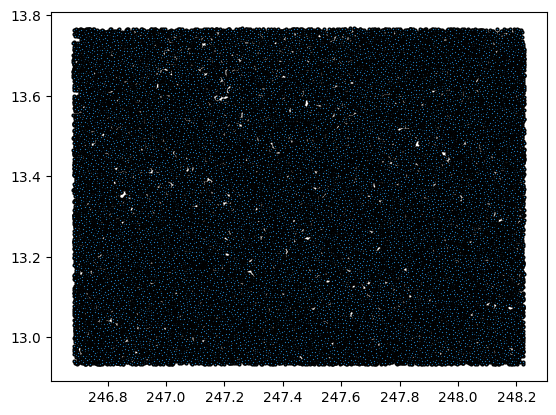

In [13]:
plot_sdss_coord(sdss)

In [14]:
gaia, gaia_path = load_gaia(center=center, width=2*ra_error, height=2*dec_error)

<Axes: xlabel='PM, mas/yr'>

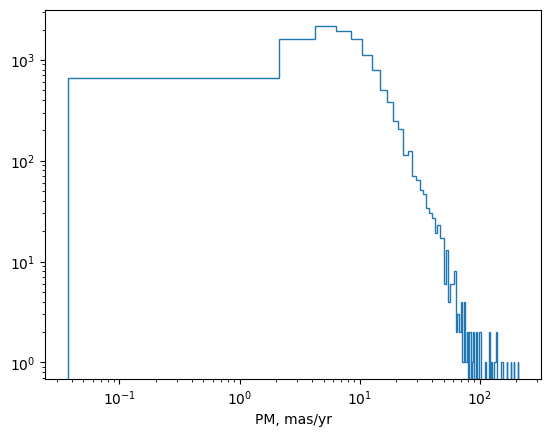

In [15]:
plt.close("all")
fig, ax = plt.subplots()
plt.hist(gaia["PM"], bins=100, histtype="step")
ax.set_xlabel("PM, mas/yr")
ax.loglog(True)
ax

# Select the cutoff of the total proper motion

$PM = \frac{v_t}{4.74d}$

where, $v_t$ is the tangential velocity in km/s, and $d$ is the distance in pc.

Assuming object velocity is <3600 km/s at distance 50 Mpc, we derive 
$\mu$ cutoff to be 0.045 mas/yr.

In [16]:
pm_cutoff = 0.045 * u.mas / u.yr

In [17]:
gaia[(gaia["pmDE"] / gaia["e_pmDE"] > 3) & (gaia["pmRA"] / gaia["e_pmRA"] > 3)]

RA_ICRS,DE_ICRS,Source,e_RA_ICRS,e_DE_ICRS,Plx,e_Plx,PM,pmRA,e_pmRA,pmDE,e_pmDE,RUWE,FG,e_FG,Gmag,FBP,e_FBP,BPmag,FRP,e_FRP,RPmag,BP-RP,RV,e_RV,Vbroad,GRVSmag,QSO,Gal,NSS,XPcont,XPsamp,RVS,EpochPh,EpochRV,MCMCGSP,MCMCMSC,And,Teff,logg,[Fe/H],Dist,A0,HIP,PS1,SDSS13,SKYM2,TYC2,URAT1,AllWISE,APASS9,GSC23,RAVE5,2MASS,RAVE6,RAJ2000,DEJ2000
deg,deg,,mas,mas,mas,mas,mas / yr,mas / yr,mas / yr,mas / yr,mas / yr,,,,mag,,,mag,,,mag,mag,km / s,km / s,km / s,mag,,,,,,,,,,,,K,log(cm.s**-2),,pc,mag,,,,,,,,,,,,,deg,deg
float64,float64,int64,float64,float64,float64,float32,float64,float64,float32,float64,float32,float64,float64,float32,float64,float32,float32,float64,float32,float32,float64,float64,float64,float32,float64,float64,uint8,uint8,uint8,uint8,uint8,uint8,uint8,uint8,uint8,uint8,uint8,float64,float64,float64,float64,float64,int32,int64,int64,int32,bytes12,bytes15,bytes19,int32,bytes10,bytes16,bytes17,bytes21,float64,float64
247.83405968825,12.94979479914,4460369819464989952,0.3169,0.2324,0.4268,0.4575,15.937,2.122,0.360,15.795,0.305,1.035,192.22420,0.5397,19.977846,54.43,4.737,20.998955,255.3,5.137,18.730360,2.268595,--,--,--,--,0,0,0,0,0,0,0,0,0,0,0,--,--,--,--,--,--,123542478340540228,1237665548904170352,--,--,URAT1-515201620,J163120.17+125659.2,--,N3XF006715,--,16312020+1256586,--,247.83405000946,12.94972459881
247.75050319938,12.93797037723,4460370300501314560,0.1410,0.0980,1.0147,0.1944,7.866,6.569,0.161,4.328,0.136,1.027,540.13030,0.7418,18.856121,147,5.327,19.920008,518.9,7.887,17.960163,1.959845,--,--,--,--,0,0,0,0,0,0,0,0,1,0,0,3563.5,4.4478,-1.6870,618.5284,0.0229,--,123522477504836065,1237665567158305244,--,--,URAT1-515201524,--,--,N3XF006559,--,16310008+1256163,--,247.75047324508,12.93795114108
247.76896107074,12.94781844778,4460370682754976896,0.2043,0.1414,2.0086,0.2780,9.940,4.265,0.234,8.979,0.192,1.027,353.47726,0.6513,19.316463,72.48,3.95,20.687956,438.6,5.495,18.142725,2.545231,--,--,--,--,0,0,0,0,0,0,0,0,0,0,0,--,--,--,--,--,--,123532477689447873,1237665567158305638,--,--,URAT1-515201546,J163104.57+125652.0,--,--,--,16310457+1256521,--,247.76894162186,12.94777854333
247.77145650243,12.99419708096,4460371125135142272,0.0843,0.0603,1.0023,0.1226,3.885,2.559,0.103,2.923,0.082,0.966,1106.86725,0.8988,18.077127,385.9,6.17,18.872280,1019,6.445,17.227488,1.644793,--,--,--,--,0,0,0,0,0,0,0,0,1,1,0,4325.7,4.6728,0.0050,1236.5223,0.5141,--,123592477714503527,1237665548904104346,--,--,URAT1-515201550,J163105.15+125939.1,--,N3XF007816,--,16310515+1259387,--,247.77144482942,12.99418408816
247.56956243334,12.93414095691,4460372469461401856,0.1467,0.1039,0.3960,0.1909,6.828,5.818,0.186,3.574,0.150,1.031,483.23014,0.6767,18.976982,184.8,5.012,19.671982,415.4,5.311,18.201683,1.470299,--,--,--,--,0,0,0,0,0,0,0,0,1,0,0,4217.4,4.8246,-0.9765,1507.0032,0.0051,--,123522475695421468,1237665567158239650,--,--,URAT1-515201337,J163016.68+125602.4,--,N3XF006478,--,--,--,247.56953590340,12.93412507286
247.51966198031,12.94417410781,4460372709979579520,0.0363,0.0266,1.2828,0.0499,5.738,0.647,0.044,5.701,0.037,1.012,3943.08518,1.629,16.697777,1449,6.493,17.435925,3543,5.698,15.874552,1.561373,--,--,--,--,0,0,0,1,0,0,0,0,1,1,0,4497.4,4.6722,0.4913,795.4132,0.4574,--,123532475196543512,1237665567158174203,--,--,URAT1-515201281,J163004.71+125639.0,--,N3XF006625,--,16300471+1256389,--,247.51965903003,12.94414877001
247.60329899648,12.96341148199,4460372911843376256,0.1384,0.0975,0.4166,0.1783,3.878,2.282,0.176,3.136,0.141,0.978,563.41997,0.7391,18.810286,197.3,6.481,19.600706,526.2,5.461,17.945059,1.655647,--,--,--,--,0,0,0,0,0,0,0,0,1,0,0,3873.8,4.8996,-0.9345,921.5432,0.0051,--,123552476032846603,1237665567158239702,--,--,URAT1-515201365,--,--,--,--,--,--,247.60328858838,12.96339754571
247.66576618977,12.95769863425,4460373500253541632,0.0194,0.0142,0.7594,0.0293,0.498,0.380,0.023,0.322,0.019,0.959,13369.77496,2.907,15.372057,7096,11.77,15.710958,9022,8.364,14.859642,0.851316,--,--,--,--,0,0,0,1,0,0,0,0,1,1,0,5486.4,4.3822,-0.8460,1219.0752,0.0

In [18]:
desi_south, desi_south_path = load_desi_south(center=center, width=2*ra_error, height=2*dec_error)

In [19]:
clean_desi_south = desi_south[(desi_south["fclean"] > 0) & (desi_south["fqual"] > 0)]
clean_desi_south[:3]

id,RAJ2000,DEJ2000,release,brickid,objid,type,pstar,gmmcomp,zphot,e_zphot,fclean,fqual
,deg,deg,,,,,,,,,,
int64,float64,float64,int16,int32,int32,bytes4,float32,bytes2,float32,float32,uint8,uint8
8000405654001209,247.842218978549,12.933264585926,8000,405654,1209,REX,0.002,R4,0.537,0.083,1,1
8000405654001252,247.856579425644,12.935156161122,8000,405654,1252,PSF,0.018,P6,0.456,0.131,1,1
8000405651001250,247.143243493375,12.933896389158,8000,405651,1250,EXP,0.010,E1,0.775,0.194,1,1


In [20]:
np.count_nonzero(np.isfinite(clean_desi_south["zphot"]))

56300

In [21]:
catwise, catwise_path = load_catwise(center=center, width=2*ra_error, height=2*dec_error)
catwise[:3]

RA_ICRS,e_RA_ICRS,DE_ICRS,e_DE_ICRS,Name,nW1,mW1,nW2,mW2,RAPMdeg,e_RAPMdeg,DEPMdeg,e_DEPMdeg,pmRA,e_pmRA,pmDE,e_pmDE,snrW1pm,snrW2pm,FW1pm,e_FW1pm,FW2pm,e_FW2pm,W1mproPM,W2mproPM,pmQual,Dist,snrdELON,snrdELAT,chi2pmRA,chi2pmDE,ka,k1,k2,km,Sep,abf,WISEA
deg,arcsec,deg,arcsec,,,,,,deg,arcsec,deg,arcsec,arcsec / yr,arcsec / yr,arcsec / yr,arcsec / yr,,,ct,ct,ct,ct,mag,mag,,arcsec,,,,,,,,,arcsec,,
float64,float64,float64,float64,bytes20,int16,int16,int16,int16,float64,float64,float64,float64,float64,float64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,bytes5,float32,float64,float64,float32,float32,bytes1,bytes1,bytes1,bytes1,float32,bytes2,bytes5
247.8424152,0.4288,12.9335613,0.4910,J163122.18+125600.8,3,12,0,12,247.8424201,0.4864,12.9335721,0.5582,-0.04852,0.1845,-0.04101,0.2146,7.0,2.8,4e+01,6.0,6e+01,20.0,18.419,18.124,1N000,0.551,0.269,0.520,0.19,0.27,3,3,3,3,--,00,WISEA
247.8519455,0.3628,12.9366735,0.4032,J163124.47+125612.0,3,12,3,12,247.8519716,0.3585,12.9366690,0.3941,0.01741,0.1379,-0.06923,0.1471,6.7,7.6,4e+01,6.0,1e+02,20.0,18.437,17.104,1N000,0.815,0.783,0.647,0.5,0.55,3,3,3,3,0.654,00,WISEA
247.8505836,0.2924,12.9402368,0.3118,J163124.14+125624.9,9,12,1,12,247.8506075,0.2907,12.9402437,0.3107,0.01734,0.1120,0.05688,0.1206,11.6,4.2,7e+01,6.0,8e+01,20.0,17.855,17.672,1N000,0.554,0.833,0.157,0.015,0.33,3,3,3,3,1.324,00,WISEA


In [22]:
ned_lvs = load_ned_lvs("../undone/NEDLVS_20250602.fits", center=center, width=2*ra_error, height=2*dec_error)

In [23]:
ned_lvs[:3]

objname,ra,dec,objtype,z,z_unc,z_tech,z_qual,z_qual_flag,z_refcode,ziDist,ziDist_unc,ziDist_method,ziDist_indicator,ziDist_refcode,DistMpc,DistMpc_unc,DistMpc_method,ebv,A_FUV_MWext,A_NUV_MWext,A_J_MWext,A_H_MWext,A_Ks_MWext,A_W1_MWext,A_W2_MWext,A_W3_MWext,A_W4_MWext,m_FUV,m_FUV_unc,m_NUV,m_NUV_unc,Lum_FUV,Lum_FUV_unc,Lum_NUV,Lum_NUV_unc,GALEXphot,m_J,m_J_unc,m_H,m_H_unc,m_Ks,m_Ks_unc,Lum_J,Lum_J_unc,Lum_H,Lum_H_unc,Lum_Ks,Lum_Ks_unc,tMASSphot,m_W1,m_W1_unc,m_W2,m_W2_unc,m_W3,m_W3_unc,m_W4,m_W4_unc,Lum_W1,Lum_W1_unc,Lum_W2,Lum_W2_unc,Lum_W3,Lum_W3_unc,Lum_W4,Lum_W4_unc,WISEphot,SFR_W4,SFR_W4_unc,SFR_hybrid,SFR_hybrid_unc,ET_flag,Mstar,Mstar_unc,MLratio
bytes30,float64,float64,bytes6,float32,float32,bytes4,bool,bool,bytes19,float64,float64,bytes30,bytes1,bytes19,float32,float32,bytes30,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64,float64,bytes5,float32,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,float64,bytes5,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,bytes5,float64,float64,float64,float64,bool,float64,float64,float32
CGCG 080-043 NED01,247.89912,13.63714,G,2.597e-02,3.1000e-05,SPEC,False,False,2007SDSS6.C...0000:,67.60,6.23,Tully-Fisher,S,2013AJ....146...86T,67.60,6.23,zIndependent,0.0448,0.359,0.402,0.036,0.023,0.016,0.009,0.006,0.002,0.001,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,False,--,--,0.5000
SDSS J162732.19+133503.0,246.88416,13.58418,G,1.626e-02,1.9347e-04,SPEC,False,False,2018ApJ...861...49H,--,--,--,--,--,70.94,0.83,Redshift,0.0432,0.346,0.388,0.035,0.022,0.015,0.009,0.006,0.002,0.001,20.742,99.000,20.509,0.246,3.0009e+41,--,2.5860e+41,5.8680e+40,ASC,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,False,--,--,0.5000
AGC 268017,246.87583,13.57083,RadioS,1.626e-02,1.9300e-04,SPEC,False,False,2011AJ....142..170H,--,--,--,--,--,70.94,0.83,Redshift,0.0429,0.343,0.385,0.035,0.022,0.015,0.009,0.006,0.002,0.001,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,False,--,--,0.5000


In [24]:
gladep, gladep_path = load_gladep(center=center, width=2*ra_error, height=2*dec_error)

In [25]:
gladep[:3]

GLADE+,PGC,GWGC,HyperLEDA,2MASS,WISExSCOS,SDSS-DR16Q,Type,RAJ2000,DEJ2000,Bmag,f_Bmag,BMAG,Jmag,Hmag,Kmag,W1mag,W2mag,f_W1mag,Bjmag,zhelio,zcmb,f_zcmb,dL,f_dL,M*,f_M*,logRate
,,,,,,,,deg,deg,mag,,mag,mag,mag,mag,mag,mag,,mag,,,,Mpc,,1e+10 solMass,,log(Gyr)
int32,int32,bytes28,bytes29,bytes16,bytes19,bytes18,bytes1,float64,float64,float64,uint8,float64,float64,float64,float64,float64,float64,uint8,float64,float64,float64,uint8,float64,uint8,float64,uint8,float32
4888,--,-,1431498,16274784+1327250,J162747.98+132724.9,-,G,246.949371,13.456968,17.160000,0,-18.766700,15.855000,14.916000,14.786000,14.340000,14.148000,0,--,0.034407257203600,0.033721476381467,1,153.230793,1,0.30000,1,3.7
5870,--,-,1438668,16322716+1343218,J163227.16+134322.2,-,G,248.113205,13.722725,17.790000,0,-19.210200,15.023000,14.219000,14.021000,13.546000,13.252000,0,--,0.054466257233100,0.054640000000000,1,251.210513,1,2.00000,1,4.5
81169,--,-,-,16290900+1332483,-,-,G,247.287521,13.546757,16.360267,1,-20.500300,13.712000,13.057000,12.612000,12.650000,--,1,15.936000,0.051194000000000,0.051386000000000,1,235.570908,1,3.00000,--,4.9


In [26]:
sdss.rename_columns(["RA_ICRS", "DE_ICRS"], ["ra", "dec"])

In [27]:
catwise.rename_columns(["RA_ICRS", "DE_ICRS"], ["ra", "dec"])
catwise.rename_columns(["W1mproPM", "W2mproPM"], ["W1", "W2"])

In [28]:
clean_desi_south.rename_columns(["RAJ2000", "DEJ2000"], ["ra", "dec"])

In [29]:
gladep.rename_columns(["RAJ2000", "DEJ2000", "dL"], ["ra", "dec", "D_L"])

In [30]:
ned_lvs.rename_columns(["DistMpc", "DistMpc_unc"], ["D_L", "e_D_L"])

In [31]:
# Rename catalogs
sdss.meta["NAME"] = "SDSS-DR16"
ned_lvs.meta["NAME"] = "NED-LVS"
catwise.meta["NAME"] = "CatWISE"
clean_desi_south.meta["NAME"] = desi_south.meta["NAME"] = "DESI-DR8"
gaia.meta["NAME"] = "GAIA-DR3"
gladep.meta["NAME"] = "GLADE+"

In [32]:
ned_lvs["ra"].unit = u.deg
ned_lvs["dec"].unit = u.deg
ned_lvs["D_L"].unit = u.Mpc
ned_lvs["e_D_L"].unit = u.Mpc
ned_lvs["objtype"].format = "%s"
ned_lvs["objtype"] = ned_lvs["objtype"].astype(str)

In [33]:
gaia.rename_columns(["RA_ICRS", "DE_ICRS"], ["ra", "dec"])

In [34]:
catwise["is_qso"] = catwise["W1"] - catwise["W2"] >= 0.8

In [35]:
n_sigma = 3
sdss_zsp_mask = np.isfinite(sdss["zsp"])
sdss_zphot_mask = ~sdss_zsp_mask & np.isfinite(sdss["zph"])
sdss["D_L"] = np.nan * u.Mpc
sdss["e_D_L"] = np.nan * u.Mpc
sdss["D_L_low"] = np.nan * u.Mpc
sdss["D_L_high"] = np.nan * u.Mpc
# Spectroscopic: zero error, symmetric point interval
sdss["D_L"][sdss_zsp_mask] = cosmos.luminosity_distance(sdss["zsp"][sdss_zsp_mask])
sdss["e_D_L"][sdss_zsp_mask] = 0.0 * u.Mpc
sdss["D_L_low"][sdss_zsp_mask] = sdss["D_L"][sdss_zsp_mask]
sdss["D_L_high"][sdss_zsp_mask] = sdss["D_L"][sdss_zsp_mask]
# Photometric: asymmetric 3σ bounds to correctly capture d_L(z) nonlinearity
sdss["D_L"][sdss_zphot_mask] = cosmos.luminosity_distance(sdss["zph"][sdss_zphot_mask])
sdss["e_D_L"][sdss_zphot_mask] = (cosmos.luminosity_distance(sdss["zph"][sdss_zphot_mask] + sdss["e_zph"][sdss_zphot_mask]) - sdss["D_L"][sdss_zphot_mask])
sdss["D_L_low"][sdss_zphot_mask] = cosmos.luminosity_distance(
    np.maximum(0, sdss["zph"][sdss_zphot_mask] - n_sigma * sdss["e_zph"][sdss_zphot_mask])
)
sdss["D_L_high"][sdss_zphot_mask] = cosmos.luminosity_distance(
    sdss["zph"][sdss_zphot_mask] + n_sigma * sdss["e_zph"][sdss_zphot_mask]
)

In [36]:
sdss['D_L', 'e_D_L', 'zph', 'e_zph']

D_L,e_D_L,zph,e_zph
Mpc,Mpc,,
float64,float64,float32,float32
nan,nan,--,--
nan,nan,--,--
nan,nan,--,--
1501.4532628301486,450.6390432296578,0.2827,0.0721
nan,nan,--,--
1643.826403820864,692.1678291660114,0.3059,0.1076
nan,nan,--,--
nan,nan,--,--


In [37]:
high_PM = np.zeros(len(gaia), dtype=bool)
high_PM[(np.abs(gaia["pmRA"]) / gaia["e_pmRA"] > 4) & (np.abs(gaia["pmDE"]) / gaia["e_pmDE"] > 4)] = True


In [38]:
gaia["high_PM"] = high_PM

In [39]:
clean_desi_south

id,ra,dec,release,brickid,objid,type,pstar,gmmcomp,zphot,e_zphot,fclean,fqual
,deg,deg,,,,,,,,,,
int64,float64,float64,int16,int32,int32,bytes4,float32,bytes2,float32,float32,uint8,uint8
8000405654001209,247.842218978549,12.933264585926,8000,405654,1209,REX,0.002,R4,0.537,0.083,1,1
8000405654001252,247.856579425644,12.935156161122,8000,405654,1252,PSF,0.018,P6,0.456,0.131,1,1
8000405651001250,247.143243493375,12.933896389158,8000,405651,1250,EXP,0.010,E1,0.775,0.194,1,1
8000405651001276,247.150784633815,12.934735989296,8000,405651,1276,REX,0.007,R0,0.755,0.177,1,1
8000405651001287,247.145592523898,12.934728193268,8000,405651,1287,REX,0.001,R7,0.966,0.187,1,1
8000405651001331,247.147624339433,12.936614442692,8000,405651,1331,PSF,0.005,P3,0.846,0.237,1,1
8000405651001332,247.147381916530,12.935747765191,8000,405651,1332,PSF,0.025,P6,0.504,0.108,1,1
8000405651001355,247.152465934776,12.937623184648,8000,405651,1355,REX,0.010,R7,0.452,0.103,1,1


In [40]:
np.count_nonzero(~np.isfinite(clean_desi_south['zphot']))

0

In [41]:
# clean_desi_so.ipynb_checkpoints/th.rename_columns(["RAJ2000", "DEJ2000"], ["ra", "dec"])
n_sigma = 3
clean_desi_south["D_L"] = cosmos.luminosity_distance(clean_desi_south["zphot"])
clean_desi_south["e_D_L"] = (cosmos.luminosity_distance(clean_desi_south["zphot"] + clean_desi_south["e_zphot"]) - clean_desi_south["D_L"])
# Asymmetric 3σ bounds — correctly accounts for d_L(z) nonlinearity at large σ_z
clean_desi_south["D_L_low"] = cosmos.luminosity_distance(
    np.maximum(0, clean_desi_south["zphot"] - n_sigma * clean_desi_south["e_zphot"])
)
clean_desi_south["D_L_high"] = cosmos.luminosity_distance(
    clean_desi_south["zphot"] + n_sigma * clean_desi_south["e_zphot"]
)

In [42]:
clean_desi_south

id,ra,dec,release,brickid,objid,type,pstar,gmmcomp,zphot,e_zphot,fclean,fqual,D_L,e_D_L,D_L_low,D_L_high
,deg,deg,,,,,,,,,,,Mpc,Mpc,Mpc,Mpc
int64,float64,float64,int16,int32,int32,bytes4,float32,bytes2,float32,float32,uint8,uint8,float64,float64,float64,float64
8000405654001209,247.842218978549,12.933264585926,8000,405654,1209,REX,0.002,R4,0.537,0.083,1,1,3188.4583719249563,603.4043784108253,1533.751263245908,5061.763869105077
8000405654001252,247.856579425644,12.935156161122,8000,405654,1252,PSF,0.018,P6,0.456,0.131,1,1,2622.794939962707,926.4332419964949,293.39183686577786,5563.150099600447
8000405651001250,247.143243493375,12.933896389158,8000,405651,1250,EXP,0.010,E1,0.775,0.194,1,1,4975.251082179201,1568.7840204617805,976.1388877438359,9906.40764620894
8000405651001276,247.150784633815,12.934735989296,8000,405651,1276,REX,0.007,R0,0.755,0.177,1,1,4818.769769452828,1419.400972186926,1153.0067227968088,9272.315697751641
8000405651001287,247.145592523898,12.934728193268,8000,405651,1287,REX,0.001,R7,0.966,0.187,1,1,6519.12712431841,1586.7166288630524,2279.5057527696526,11453.518552294161
8000405651001331,247.147624339433,12.936614442692,8000,405651,1331,PSF,0.005,P3,0.846,0.237,1,1,5539.052508554205,1965.0391960075876,659.3340276733377,11730.456579663678
8000405651001332,247.147381916530,12.935747765191,8000,405651,1332,PSF,0.025,P6,0.504,0.108,1,1,2955.099713510082,777.6225990342004,903.5026751688288,5394.928026087136
8000405651001355,247.152465934776,12.937623184648,8000,405651,1355,REX,0.010,R7,0.452,0.103,1,1,2595.4988871582946,721.8588103125094,701.9018134660297,4865.60350940197


In [43]:
clean_desi_south[clean_desi_south['id'] == 8000407058005490]

id,ra,dec,release,brickid,objid,type,pstar,gmmcomp,zphot,e_zphot,fclean,fqual,D_L,e_D_L,D_L_low,D_L_high
,deg,deg,,,,,,,,,,,Mpc,Mpc,Mpc,Mpc
int64,float64,float64,int16,int32,int32,bytes4,float32,bytes2,float32,float32,uint8,uint8,float64,float64,float64,float64
8000407058005490,247.909703588168,13.360433249215,8000,407058,5490,REX,0.003,R3,0.533,0.065,1,1,3159.9663132340456,469.75133001081804,1844.9640480777991,4609.222232794962


In [44]:
print("Statistics")
print(f"SDSS: {len(sdss)} sources")
print(f"GAIA: {len(gaia)} sources")
print(f"GLADE: {len(gladep)} sources")
print(f"NED: {len(ned_lvs)} sources")
print(f"CATWISE: {len(catwise)} sources")
print(f"DESI: {len(clean_desi_south)} sources")

Statistics
SDSS: 54935 sources
GAIA: 14485 sources
GLADE: 1243 sources
NED: 208 sources
CATWISE: 48733 sources
DESI: 56300 sources


In [45]:
ned = Table.read("../undone/NEDLVS_20250602.fits", format="fits")

In [46]:
len(ned) / (4*np.pi*u.sr).to(u.deg ** 2)

<Quantity 50.99590275 1 / deg2>

In [47]:
len(ned_lvs) / localization_area

<Quantity 166.4 1 / deg2>

# Cross-match tables and create a single master table

In [48]:
# def hstack_tables(*tables: tuple[Table], seplimit: u.Unit = 3.0 * u.arcsec) -> Table:
#     master_table = tables[0].copy()
#     master_name = master_table.meta["NAME"]
#     master_table.rename_columns([c for c in master_table.colnames], [f"{c}_{master_name}" for c in master_table.colnames])
#     master_table["ra_match"] = master_table[f"ra_{master_name}"]
#     master_table["dec_match"] = master_table[f"dec_{master_name}"]

#     if len(tables) > 1:
#         for t in tables[1:]:
#             # FIX: координаты мастера должны считаться на каждой итерации
#             # из текущего master_table (после предыдущих vstack/sort)
#             master_coord = SkyCoord(master_table["ra_match"], master_table["dec_match"])

#             master_idx_orig = np.arange(len(master_table))
#             tab = t.copy()
#             tab_name = tab.meta["NAME"]
#             tab.rename_columns([c for c in tab.colnames], [f"{c}_{tab_name}" for c in tab.colnames])
#             tab_coord = SkyCoord(tab[f"ra_{tab_name}"], tab[f"dec_{tab_name}"])
#             master_idx, sep, _ = tab_coord.match_to_catalog_sky(master_coord)
#             match_mask = sep < seplimit
#             tab_idx = np.arange(len(tab))[match_mask]
#             master_idx = master_idx[match_mask]

#             master_table_top = hstack_table([master_table[master_idx], tab[tab_idx]], join_type="exact")
#             master_table_bottom = master_table[np.setdiff1d(master_idx_orig, master_idx)]
#             tab_unmatched = tab[~match_mask].copy()
#             if len(tab_unmatched):
#                 tab_unmatched["ra_match"] = tab_unmatched[f"ra_{tab_name}"]
#                 tab_unmatched["dec_match"] = tab_unmatched[f"dec_{tab_name}"]
#                 master_table_bottom = vstack_table([master_table_bottom, tab_unmatched], join_type="outer")
#             master_table = vstack_table([master_table_top, master_table_bottom], join_type="outer")
#             master_table.sort([f"ra_{master_name}", f"dec_{master_name}"])

#     return master_table

In [163]:
def hstack_tables(*tables: tuple[Table], seplimit: u.Unit = 3.0 * u.arcsec) -> Table:
    master_table = tables[0].copy()
    master_name = master_table.meta["NAME"]
    master_table.rename_columns([c for c in master_table.colnames], [f"{c}_{master_name}" for c in master_table.colnames])
    master_table["ra_match"] = master_table[f"ra_{master_name}"]
    master_table["dec_match"] = master_table[f"dec_{master_name}"]

    if len(tables) > 1:
        for t in tables[1:]:
            # FIX: координаты мастера должны считаться на каждой итерации
            # из текущего master_table (после предыдущих vstack/sort)
            master_coord = SkyCoord(master_table["ra_match"], master_table["dec_match"])

            master_idx_orig = np.arange(len(master_table))
            tab = t.copy()
            tab_name = tab.meta["NAME"]
            tab.rename_columns([c for c in tab.colnames], [f"{c}_{tab_name}" for c in tab.colnames])
            tab_coord = SkyCoord(tab[f"ra_{tab_name}"], tab[f"dec_{tab_name}"])
            master_idx, sep, _ = tab_coord.match_to_catalog_sky(master_coord)
            match_mask = sep < seplimit
            tab_idx    = np.arange(len(tab))[match_mask]
            master_idx = master_idx[match_mask]
            sep_matched = sep[match_mask]

            # Bug fix: match_to_catalog_sky — many-to-one: несколько объектов tab
            # могут указывать на одну строку master, дублируя её в master_table_top.
            # Оставляем только ближайший tab-объект для каждой строки master.
            best = {}  # master_row_idx → (tab_idx, sep)
            for ti, mi, si in zip(tab_idx, master_idx, sep_matched):
                if mi not in best or si < best[mi][1]:
                    best[mi] = (ti, si)
            unique_master_idx = np.array(sorted(best.keys()),                       dtype=int)
            unique_tab_idx    = np.array([best[m][0] for m in sorted(best.keys())], dtype=int)

            master_table_top = hstack_table(
                [master_table[unique_master_idx], tab[unique_tab_idx]],
                join_type="exact"
            )
            master_table_bottom = master_table[np.setdiff1d(master_idx_orig, unique_master_idx)]
            tab_unmatched = tab[np.setdiff1d(np.arange(len(tab)), unique_tab_idx)].copy()
            if len(tab_unmatched):
                tab_unmatched["ra_match"] = tab_unmatched[f"ra_{tab_name}"]
                tab_unmatched["dec_match"] = tab_unmatched[f"dec_{tab_name}"]
                master_table_bottom = vstack_table([master_table_bottom, tab_unmatched], join_type="outer")
            master_table = vstack_table([master_table_top, master_table_bottom], join_type="outer")
            master_table.sort([f"ra_{master_name}", f"dec_{master_name}"])

    return master_table

In [170]:
master_table = hstack_tables(sdss, catwise, gaia, gladep, ned_lvs, clean_desi_south)

In [171]:
def fix_sdss_ids_and_deduplicate(master_table, sdss_dedup, match_radius_arcsec=2.0):
    """
    1. For every row that has SDSS data, replace `objID_SDSS-DR16` with the correct ID
       from the deduplicated SDSS table by matching coordinates.
    2. Remove duplicate rows that have the same SDSS objID (keep first occurrence).
    """
    # Identify SDSS coordinate columns
    ra_col = next((c for c in master_table.colnames if c.startswith("ra_") and "SDSS" in c), None)
    dec_col = next((c for c in master_table.colnames if c.startswith("dec_") and "SDSS" in c), None)
    if ra_col is None or dec_col is None:
        raise ValueError("SDSS coordinate columns not found in master_table")
    
    # Rows with valid SDSS coordinates
    has_sdss = np.isfinite(master_table[ra_col]) & (master_table[ra_col] != 0.0)
    if not np.any(has_sdss):
        return master_table
    
    # Match to original SDSS
    master_coords = SkyCoord(master_table[ra_col][has_sdss], master_table[dec_col][has_sdss])
    sdss_coords = SkyCoord(sdss_dedup["ra"], sdss_dedup["dec"])
    sdss_ids = sdss_dedup["objID"]
    
    idx, sep, _ = master_coords.match_to_catalog_sky(sdss_coords)
    good = sep.to_value(u.arcsec) < match_radius_arcsec
    
    # Convert current objID column to plain int64 (handling masks)
    current_ids = master_table["objID_SDSS-DR16"]
    if hasattr(current_ids, 'mask') and current_ids.mask is not np.ma.nomask:
        new_ids = current_ids.filled(0).astype(np.int64)   # masked -> 0
    else:
        new_ids = np.asarray(current_ids, dtype=np.int64)
    
    # Update matched rows
    master_indices = np.where(has_sdss)[0][good]
    new_ids[master_indices] = sdss_ids[idx[good]]
    master_table["objID_SDSS-DR16"] = new_ids
    
    print(f"Corrected {len(master_indices)} SDSS objIDs.")
    
    return master_table

# Apply the fix
master_table = fix_sdss_ids_and_deduplicate(master_table, sdss, match_radius_arcsec=2.0)

Corrected 54935 SDSS objIDs.


In [173]:
# Verify specific objID
row = master_table[master_table["objID_SDSS-DR16"] == 1237665531726530223]
print(f"Found {len(row)} row(s) for objID 1237665531726530223")  # should be 1

# Check duplicates
from collections import Counter
counts = Counter(master_table["objID_SDSS-DR16"])
dups = [oid for oid, c in counts.items() if c > 1]
print(f"Duplicates: {dups}")  # should be []

Found 1 row(s) for objID 1237665531726530223


Duplicates: [0]


In [174]:
master_table[:10][["ra_SDSS-DR16", "dec_SDSS-DR16", "ra_CatWISE", "dec_CatWISE", "ra_GAIA-DR3", "dec_GAIA-DR3", "ra_DESI-DR8", "dec_DESI-DR8", "D_L_GLADE+"]]

ra_SDSS-DR16,dec_SDSS-DR16,ra_CatWISE,dec_CatWISE,ra_GAIA-DR3,dec_GAIA-DR3,ra_DESI-DR8,dec_DESI-DR8,D_L_GLADE+
deg,deg,deg,deg,deg,deg,deg,deg,Mpc
float64,float64,float64,float64,float64,float64,float64,float64,float64
246.682351,13.700876,246.6823090,13.7008574,246.68233015078,13.70086743507,--,--,--
246.682555,13.689519,246.6824980,13.6897104,--,--,--,--,--
246.682609,13.660220,246.6824887,13.6601747,246.68248853722,13.66017279643,--,--,--
246.682649,13.731373,--,--,--,--,246.683061186529,13.731259319909,--
246.682894,13.551177,246.6830313,13.5512469,246.68290173093,13.55119604927,--,--,--
246.682984,13.644981,--,--,--,--,246.682902711761,13.644966186284,--
246.683036,13.650131,--,--,--,--,--,--,--
246.683263,13.495041,--,--,--,--,--,--,--


In [175]:
master_table

objID_SDSS-DR16,ra_SDSS-DR16,dec_SDSS-DR16,mode_SDSS-DR16,class_SDSS-DR16,clean_SDSS-DR16,e_RA_ICRS_SDSS-DR16,e_DE_ICRS_SDSS-DR16,umag_SDSS-DR16,gmag_SDSS-DR16,rmag_SDSS-DR16,imag_SDSS-DR16,zmag_SDSS-DR16,e_umag_SDSS-DR16,e_gmag_SDSS-DR16,e_rmag_SDSS-DR16,e_imag_SDSS-DR16,e_zmag_SDSS-DR16,zsp_SDSS-DR16,e_zsp_SDSS-DR16,f_zsp_SDSS-DR16,zph_SDSS-DR16,e_zph_SDSS-DR16,<zph>_SDSS-DR16,Q_SDSS-DR16,SDSS16_SDSS-DR16,Sp-ID_SDSS-DR16,MJD_SDSS-DR16,D_L_SDSS-DR16,e_D_L_SDSS-DR16,D_L_low_SDSS-DR16,D_L_high_SDSS-DR16,ra_match,dec_match,ra_CatWISE,e_RA_ICRS_CatWISE,dec_CatWISE,e_DE_ICRS_CatWISE,Name_CatWISE,nW1_CatWISE,mW1_CatWISE,nW2_CatWISE,mW2_CatWISE,RAPMdeg_CatWISE,e_RAPMdeg_CatWISE,DEPMdeg_CatWISE,e_DEPMdeg_CatWISE,pmRA_CatWISE,e_pmRA_CatWISE,pmDE_CatWISE,e_pmDE_CatWISE,snrW1pm_CatWISE,snrW2pm_CatWISE,FW1pm_CatWISE,e_FW1pm_CatWISE,FW2pm_CatWISE,e_FW2pm_CatWISE,W1_CatWISE,W2_CatWISE,pmQual_CatWISE,Dist_CatWISE,snrdELON_CatWISE,snrdELAT_CatWISE,chi2pmRA_CatWISE,chi2pmDE_CatWISE,ka_CatWISE,k1_CatWISE,k2_CatWISE,km_CatWISE,Sep_CatWISE,abf_CatWISE,WISEA_CatWISE,is_qso_CatWISE,ra_GAIA-DR3,dec_GAIA-DR3,Source_GAIA-DR3,e_RA_ICRS_GAIA-DR3,e_DE_ICRS_GAIA-DR3,Plx_GAIA-DR3,e_Plx_GAIA-DR3,PM_GAIA-DR3,pmRA_GAIA-DR3,e_pmRA_GAIA-DR3,pmDE_GAIA-DR3,e_pmDE_GAIA-DR3,RUWE_GAIA-DR3,FG_GAIA-DR3,e_FG_GAIA-DR3,Gmag_GAIA-DR3,FBP_GAIA-DR3,e_FBP_GAIA-DR3,BPmag_GAIA-DR3,FRP_GAIA-DR3,e_FRP_GAIA-DR3,RPmag_GAIA-DR3,BP-RP_GAIA-DR3,RV_GAIA-DR3,e_RV_GAIA-DR3,Vbroad_GAIA-DR3,GRVSmag_GAIA-DR3,QSO_GAIA-DR3,Gal_GAIA-DR3,NSS_GAIA-DR3,XPcont_GAIA-DR3,XPsamp_GAIA-DR3,RVS_GAIA-DR3,EpochPh_GAIA-DR3,EpochRV_GAIA-DR3,MCMCGSP_GAIA-DR3,MCMCMSC_GAIA-DR3,And_GAIA-DR3,Teff_GAIA-DR3,logg_GAIA-DR3,[Fe/H]_GAIA-DR3,Dist_GAIA-DR3,A0_GAIA-DR3,HIP_GAIA-DR3,PS1_GAIA-DR3,SDSS13_GAIA-DR3,SKYM2_GAIA-DR3,TYC2_GAIA-DR3,URAT1_GAIA-DR3,AllWISE_GAIA-DR3,APASS9_GAIA-DR3,GSC23_GAIA-DR3,RAVE5_GAIA-DR3,2MASS_GAIA-DR3,RAVE6_GAIA-DR3,RAJ2000_GAIA-DR3,DEJ2000_GAIA-DR3,high_PM_GAIA-DR3,GLADE+_GLADE+,PGC_GLADE+,GWGC_GLADE+,HyperLEDA_GLADE+,2MASS_GLADE+,WISExSCOS_GLADE+,SDSS-DR16Q_GLADE+,Type_GLADE+,ra_GLADE+,dec_GLADE+,Bmag_GLADE+,f_Bmag_GLADE+,BMAG_GLADE+,Jmag_GLADE+,Hmag_GLADE+,Kmag_GLADE+,W1mag_GLADE+,W2mag_GLADE+,f_W1mag_GLADE+,Bjmag_GLADE+,zhelio_GLADE+,zcmb_GLADE+,f_zcmb_GLADE+,D_L_GLADE+,f_dL_GLADE+,M*_GLADE+,f_M*_GLADE+,logRate_GLADE+,objname_NED-LVS,ra_NED-LVS,dec_NED-LVS,objtype_NED-LVS,z_NED-LVS,z_unc_NED-LVS,z_tech_NED-LVS,z_qual_NED-LVS,z_qual_flag_NED-LVS,z_refcode_NED-LVS,ziDist_NED-LVS,ziDist_unc_NED-LVS,ziDist_method_NED-LVS,ziDist_indicator_NED-LVS,ziDist_refcode_NED-LVS,D_L_NED-LVS,e_D_L_NED-LVS,DistMpc_method_NED-LVS,ebv_NED-LVS,A_FUV_MWext_NED-LVS,A_NUV_MWext_NED-LVS,A_J_MWext_NED-LVS,A_H_MWext_NED-LVS,A_Ks_MWext_NED-LVS,A_W1_MWext_NED-LVS,A_W2_MWext_NED-LVS,A_W3_MWext_NED-LVS,A_W4_MWext_NED-LVS,m_FUV_NED-LVS,m_FUV_unc_NED-LVS,m_NUV_NED-LVS,m_NUV_unc_NED-LVS,Lum_FUV_NED-LVS,Lum_FUV_unc_NED-LVS,Lum_NUV_NED-LVS,Lum_NUV_unc_NED-LVS,GALEXphot_NED-LVS,m_J_NED-LVS,m_J_unc_NED-LVS,m_H_NED-LVS,m_H_unc_NED-LVS,m_Ks_NED-LVS,m_Ks_unc_NED-LVS,Lum_J_NED-LVS,Lum_J_unc_NED-LVS,Lum_H_NED-LVS,Lum_H_unc_NED-LVS,Lum_Ks_NED-LVS,Lum_Ks_unc_NED-LVS,tMASSphot_NED-LVS,m_W1_NED-LVS,m_W1_unc_NED-LVS,m_W2_NED-LVS,m_W2_unc_NED-LVS,m_W3_NED-LVS,m_W3_unc_NED-LVS,m_W4_NED-LVS,m_W4_unc_NED-LVS,Lum_W1_NED-LVS,Lum_W1_unc_NED-LVS,Lum_W2_NED-LVS,Lum_W2_unc_NED-LVS,Lum_W3_NED-LVS,Lum_W3_unc_NED-LVS,Lum_W4_NED-LVS,Lum_W4_unc_NED-LVS,WISEphot_NED-LVS,SFR_W4_NED-LVS,SFR_W4_unc_NED-LVS,SFR_hybrid_NED-LVS,SFR_hybrid_unc_NED-LVS,ET_flag_NED-LVS,Mstar_NED-LVS,Mstar_unc_NED-LVS,MLratio_NED-LVS,id_DESI-DR8,ra_DESI-DR8,dec_DESI-DR8,release_DESI-DR8,brickid_DESI-DR8,objid_DESI-DR8,type_DESI-DR8,pstar_DESI-DR8,gmmcomp_DESI-DR8,zphot_DESI-DR8,e_zphot_DESI-DR8,fclean_DESI-DR8,fqual_DESI-DR8,D_L_DESI-DR8,e_D_L_DESI-DR8,D_L_low_DESI-DR8,D_L_high_DESI-DR8
,deg,deg,,,,arcsec,arcsec,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,,,,,,,,,,d,Mpc,Mpc,Mpc,Mpc,deg,deg,deg,arcsec,deg,arcsec,,,,,,deg,arcsec,deg,arcsec,arcsec / yr,arcsec / yr,arcsec / yr,arcse

In [176]:
master_table.write("master_table_new.fit", format="fits", overwrite=True)

# Size of the Galaxy

$D = 26.8 \pm 1.1$ kpc

https://ui.adsabs.harvard.edu/abs/1998Obs...118..201G

# Process the master table to have distances and classification for each source

In [180]:
def process_master_table(master_table: Table) -> Table:
    tab = master_table.copy()

    # ── 1. Average coordinates across catalogs ──────────────────────────────
    # After astropy outer-join hstack, unmatched rows carry fill value 0.0
    # (not NaN) in float coordinate columns.  isfinite(0.0) = True, so a
    # plain isfinite guard would include fill zeros in both the sum and the
    # count, pulling ra_fin/dec_fin toward 0°.
    #
    # The correct mask combines two checks:
    #   • use MaskedColumn.mask when the column retains its astropy mask
    #   • also exclude any residual fill 0.0 values for materialised columns
    # Both RA and Dec: real measurements of exactly 0.0 are astronomically
    # possible but do not appear in any of the catalogs used here, so the
    # != 0.0 guard is safe.
    def _coord_valid_mask(col_array, float_arr):
        """True where the value is a genuine measurement (not fill/NaN)."""
        m = np.zeros(len(float_arr), dtype=bool)
        # start with isfinite; also honour the astropy mask if present
        finite = np.isfinite(float_arr)
        if hasattr(col_array, "mask") and col_array.mask is not np.ma.nomask:
            not_masked = ~np.asarray(col_array.mask, dtype=bool)
        else:
            not_masked = finite  # fallback
        m = finite & not_masked & (float_arr != 0.0)
        return m

    ra_cols  = [c for c in tab.colnames if c.startswith("ra_")]
    dec_cols = [c for c in tab.colnames if c.startswith("dec_")]

    ra_avg  = np.full(len(tab), np.nan)
    dec_avg = np.full(len(tab), np.nan)

    for i in range(len(tab)):
        ra_vals, dec_vals = [], []
        for c in ra_cols:
            arr = np.asarray(tab[c], dtype=float)
            val = arr[i]
            is_valid = _coord_valid_mask(tab[c], arr)[i]
            if is_valid:
                ra_vals.append(val)
        for c in dec_cols:
            arr = np.asarray(tab[c], dtype=float)
            val = arr[i]
            is_valid = _coord_valid_mask(tab[c], arr)[i]
            if is_valid:
                dec_vals.append(val)
        if ra_vals:
            ra_avg[i]  = np.mean(ra_vals)
        if dec_vals:
            dec_avg[i] = np.mean(dec_vals)

    tab["ra_fin"]  = ra_avg
    tab["dec_fin"] = dec_avg

    # ── 2. Assign distances in priority order ───────────────────────────────
    D_L_fin    = np.full_like(ra_avg, np.nan) * u.Mpc
    e_D_L_fin  = np.full_like(ra_avg, np.nan) * u.Mpc
    D_L_low_fin  = np.full_like(ra_avg, np.nan) * u.Mpc
    D_L_high_fin = np.full_like(ra_avg, np.nan) * u.Mpc
    tab["z_src_fin"] = " " * 64
    tab["z_src_fin"].format = "%s"

    def _not_yet(D_L_fin):
        """True where no distance has been assigned yet."""
        return ~np.isfinite(D_L_fin)

    # 2a. NED-LVS spectroscopic
    mask_ned_spec = (
        np.isfinite(tab["D_L_NED-LVS"])
        & (tab["z_tech_NED-LVS"] == "SPEC")
        & _not_yet(D_L_fin)
    )
    D_L_fin[mask_ned_spec]    = tab["D_L_NED-LVS"][mask_ned_spec]
    e_D_L_fin[mask_ned_spec]  = tab["e_D_L_NED-LVS"][mask_ned_spec]
    D_L_low_fin[mask_ned_spec]  = D_L_fin[mask_ned_spec]
    D_L_high_fin[mask_ned_spec] = D_L_fin[mask_ned_spec]
    if np.count_nonzero(mask_ned_spec):
        tab["z_src_fin"][mask_ned_spec] = "NED-LVS spec"

    # 2b. SDSS-DR16 spectroscopic  (e_D_L_SDSS == 0 marks spectroscopic z)
    mask_sdss_spec = (
        np.isfinite(tab["D_L_SDSS-DR16"])
        & (tab["e_D_L_SDSS-DR16"] == 0.0)
        & _not_yet(D_L_fin)
    )
    D_L_fin[mask_sdss_spec]    = tab["D_L_SDSS-DR16"][mask_sdss_spec]
    e_D_L_fin[mask_sdss_spec]  = tab["e_D_L_SDSS-DR16"][mask_sdss_spec]
    D_L_low_fin[mask_sdss_spec]  = D_L_fin[mask_sdss_spec]
    D_L_high_fin[mask_sdss_spec] = D_L_fin[mask_sdss_spec]
    if np.count_nonzero(mask_sdss_spec):
        tab["z_src_fin"][mask_sdss_spec] = "SDSS-DR16 spec"

    # 2c. SDSS-DR16 photometric  (e_D_L_SDSS > 0 marks photometric z)
    # Bug fix: use tab["e_D_L_SDSS-DR16"] > 0, NOT e_D_L_fin > 0.
    # e_D_L_fin is NaN for unassigned sources so NaN > 0 == False,
    # which silently skipped all SDSS photometric distances.
    # Asymmetric fix: use pre-computed 3σ bounds from load_sdss (D_L_low/D_L_high)
    # instead of the old linear ×3 approximation.
    mask_sdss_phot = (
        np.isfinite(tab["D_L_SDSS-DR16"])
        & (tab["e_D_L_SDSS-DR16"] > 0.0)
        & _not_yet(D_L_fin)
    )
    D_L_fin[mask_sdss_phot]      = tab["D_L_SDSS-DR16"][mask_sdss_phot]
    e_D_L_fin[mask_sdss_phot]    = tab["e_D_L_SDSS-DR16"][mask_sdss_phot]
    D_L_low_fin[mask_sdss_phot]  = tab["D_L_low_SDSS-DR16"][mask_sdss_phot]
    D_L_high_fin[mask_sdss_phot] = tab["D_L_high_SDSS-DR16"][mask_sdss_phot]
    if np.count_nonzero(mask_sdss_phot):
        tab["z_src_fin"][mask_sdss_phot] = "SDSS-DR16 phot"

    # 2d. DESI-DR8 photometric
    # Outer-join fill values can appear as masked/0.0 entries, so require
    # a real positive and unmasked distance before DESI is allowed to
    # override SDSS/NED.
    # Asymmetric fix: use pre-computed 3σ bounds (D_L_low/D_L_high) instead
    # of the old linear ×3 approximation.
    desi_dist = tab["D_L_DESI-DR8"]
    if hasattr(desi_dist, "mask") and desi_dist.mask is not np.ma.nomask:
        desi_not_masked = ~np.asarray(desi_dist.mask, dtype=bool)
    else:
        desi_not_masked = np.ones(len(tab), dtype=bool)
    mask_desi = (
        desi_not_masked
        & np.isfinite(desi_dist)
        & (desi_dist > 0.0 * u.Mpc)
        & _not_yet(D_L_fin)
    )
    D_L_fin[mask_desi]       = tab["D_L_DESI-DR8"][mask_desi]
    e_D_L_fin[mask_desi]     = tab["e_D_L_DESI-DR8"][mask_desi]
    D_L_low_fin[mask_desi]   = tab["D_L_low_DESI-DR8"][mask_desi]
    D_L_high_fin[mask_desi]  = tab["D_L_high_DESI-DR8"][mask_desi]
    if np.count_nonzero(mask_desi):
        tab["z_src_fin"][mask_desi] = "DESI-DR8 phot"

    # 2e. NED-LVS photometric  (error × 3 to match SDSS/DESI 3-sigma convention)
    # NED-LVS does not supply z_phot columns, so we cannot form asymmetric bounds;
    # keep the symmetric ×3 approximation as the best available estimate.
    mask_ned_phot = (
        np.isfinite(tab["D_L_NED-LVS"])
        & (tab["z_tech_NED-LVS"] == "PHOT")
        & _not_yet(D_L_fin)
    )
    D_L_fin[mask_ned_phot]    = tab["D_L_NED-LVS"][mask_ned_phot]
    e_D_L_fin[mask_ned_phot]  = 3 * tab["e_D_L_NED-LVS"][mask_ned_phot]
    D_L_low_fin[mask_ned_phot]  = D_L_fin[mask_ned_phot] - 3 * tab["e_D_L_NED-LVS"][mask_ned_phot]
    D_L_high_fin[mask_ned_phot] = D_L_fin[mask_ned_phot] + 3 * tab["e_D_L_NED-LVS"][mask_ned_phot]
    if np.count_nonzero(mask_ned_phot):
        tab["z_src_fin"][mask_ned_phot] = "NED-LVS phot"

    # 2f. GLADE+ (luminosity distance, no redshift error available)
    # Bug fix: also assign e_D_L_fin = 0 so that the beyond_dist_limit
    # comparison is not NaN (which would silently keep all GLADE+ sources).
    # No z_phot error available → point interval (low = high = D_L).
    mask_gladep = (
        np.isfinite(tab["D_L_GLADE+"])
        & (tab["D_L_GLADE+"] > 0.0)
        & _not_yet(D_L_fin)
    )
    D_L_fin[mask_gladep]     = tab["D_L_GLADE+"][mask_gladep]
    e_D_L_fin[mask_gladep]   = 0.0 * u.Mpc
    D_L_low_fin[mask_gladep]  = D_L_fin[mask_gladep]
    D_L_high_fin[mask_gladep] = D_L_fin[mask_gladep]
    if np.count_nonzero(mask_gladep):
        tab["z_src_fin"][mask_gladep] = "GLADE+"

    # 2g. GAIA-DR3 parallax distance
    # Bug fix: GAIA-DR3 must come BEFORE NED-LVS unknown (steps 6 and 7
    # were swapped in the original code).
    # Point interval (no parallax error propagation into D_L bounds).
    mask_gaia = (
        np.isfinite(tab["Dist_GAIA-DR3"])
        & (tab["Dist_GAIA-DR3"] > 0.0)
        & _not_yet(D_L_fin)
    )
    D_L_fin[mask_gaia]     = tab["Dist_GAIA-DR3"][mask_gaia]
    e_D_L_fin[mask_gaia]   = 0.0 * u.Mpc
    D_L_low_fin[mask_gaia]  = D_L_fin[mask_gaia]
    D_L_high_fin[mask_gaia] = D_L_fin[mask_gaia]
    if np.count_nonzero(mask_gaia):
        tab["z_src_fin"][mask_gaia] = "GAIA-DR3"

    # 2h. NED-LVS unknown method
    # Point interval (no z_phot error available for asymmetric bounds).
    mask_ned_unkn = (
        np.isfinite(tab["D_L_NED-LVS"])
        & (tab["z_tech_NED-LVS"] == "UNKN")
        & _not_yet(D_L_fin)
    )
    D_L_fin[mask_ned_unkn]    = tab["D_L_NED-LVS"][mask_ned_unkn]
    e_D_L_fin[mask_ned_unkn]  = tab["e_D_L_NED-LVS"][mask_ned_unkn]
    D_L_low_fin[mask_ned_unkn]  = D_L_fin[mask_ned_unkn]
    D_L_high_fin[mask_ned_unkn] = D_L_fin[mask_ned_unkn]
    if np.count_nonzero(mask_ned_unkn):
        tab["z_src_fin"][mask_ned_unkn] = "NED-LVS unknown"

    # Label sources where no distance could be derived
    # Bug fix: use proper assignment (tab["col"][mask] not tab[mask]["col"])
    # to avoid the silent chained-assignment no-op.
    mask_no_dist = ~np.isfinite(D_L_fin)
    if np.count_nonzero(mask_no_dist):
        tab["z_src_fin"][mask_no_dist] = "unknown"

    tab["D_L_fin"]      = D_L_fin
    tab["e_D_L_fin"]    = e_D_L_fin
    tab["D_L_low_fin"]  = D_L_low_fin
    tab["D_L_high_fin"] = D_L_high_fin

    # ── 3. high_PM flag already computed per-row in GAIA table ─────────────
    #       (see cell above; propagated via hstack_tables as high_PM_GAIA-DR3)

    # ── 4. Source classification ────────────────────────────────────────────
    # Bug fix: klass is initialised as "Unknown", never "0.0", so all
    # (klass == "0.0") guards were always False, silently skipping SDSS,
    # CatWISE, and DESI classification steps entirely.
    # Fixed by replacing every (klass == "0.0") with (klass == "Unknown").
    klass = np.asarray(["Unknown"] * len(master_table))

    # 4a. NED-LVS classification
    # Bug fix: after astropy outer-join hstack, unmatched rows get a fill
    # value for string columns that is either b"0.0" (bytes) or "" (empty).
    # Comparing bytes b"0.0" != "0.0" (str) is ALWAYS True in Python, so
    # the original mask captured every row, overwriting "Unknown" with the
    # fill value and silently breaking all downstream SDSS/CatWISE/DESI steps.
    # Fix: decode to plain str and strip whitespace before the comparison,
    # then reject both "" and "0.0" as sentinel non-values.
    # After outer-join hstack, unmatched rows become *masked* entries in
    # astropy MaskedColumns (the .mask attribute is True for those rows).
    # Float fill values are often 0.0 (not NaN), so isfinite() is unreliable.
    # String fill values vary ("0.0", "--", "", etc.) across astropy versions.
    # The only guaranteed check is the column's own boolean mask.
    ned_col = master_table["objtype_NED-LVS"]
    ned_type_str = np.array([str(x).strip() for x in ned_col])
    if hasattr(ned_col, "mask") and ned_col.mask is not np.ma.nomask:
        # Standard path: MaskedColumn produced by outer-join hstack
        mask_has_ned = ~np.asarray(ned_col.mask, dtype=bool)
    else:
        # Fallback: column was already materialised; exclude all fill sentinels
        mask_has_ned = ~np.isin(ned_type_str, ["", "--", "0", "0.0", "nan"])
    mask_ned_class = mask_has_ned & (ned_type_str != "")
    klass[mask_ned_class] = ned_type_str[mask_ned_class]

    # 4b. SDSS-DR16  (class < 5 → galaxy, ≥ 5 → star)
    mask_sdss_g = (klass == "Unknown") & (master_table["class_SDSS-DR16"] < 5)
    mask_sdss_s = (klass == "Unknown") & (master_table["class_SDSS-DR16"] >= 5)
    klass[mask_sdss_g] = "G"
    klass[mask_sdss_s] = "S"

    # 4c. CatWISE  (W1−W2 ≥ 0.8 → QSO)
    mask_wise_qso = (klass == "Unknown") & (master_table["is_qso_CatWISE"] == True)
    klass[mask_wise_qso] = "QSO"

    # 4d. DESI-DR8  (pstar ≥ 0.5 → star, else galaxy)
    mask_desi_s = (klass == "Unknown") & (master_table["pstar_DESI-DR8"] >= 0.5)
    mask_desi_g = (klass == "Unknown") & (master_table["pstar_DESI-DR8"] < 0.5)
    klass[mask_desi_s] = "S"
    klass[mask_desi_g] = "G"

    # 4e. GAIA-DR3: high proper-motion → star
    klass[tab["high_PM_GAIA-DR3"]] = "S"

    # 4f. Galactic sources: lower distance bound < Milky Way size → star
    galactic = (
        ((tab["D_L_fin"] - tab["e_D_L_fin"]) < (26.8 + 1.1) * u.kpc)
        & (tab["D_L_fin"] > 0.0)
    )
    klass[galactic] = "S"

    tab["class_fin"] = [c for c in klass]

    # ── 5. Distance-limit flag ──────────────────────────────────────────────
    # 90% CI of GW190425: 159 +69/-71 Mpc  → [88, 228] Mpc
    # Asymmetric fix: use the nonlinear 3σ interval [D_L_low_fin, D_L_high_fin]
    # (pre-computed at load time for photo-z sources) for the overlap test,
    # rather than the old symmetric D_L ± e_D_L which underestimates the
    # lower bound at large σ_z. For point sources (spec, GLADE+, GAIA)
    # D_L_low_fin == D_L_high_fin == D_L_fin, so behaviour is unchanged.
    # A source is within distance if its interval OVERLAPS [gw_low, gw_high]:
    #   overlap  ↔  D_L_high_fin >= gw_low  AND  D_L_low_fin <= gw_high
    #   beyond   ↔  NOT overlap
    gw_low  = dist_mean - dist_nerr   # 88 Mpc
    gw_high = dist_mean + dist_perr   # 228 Mpc
    # For sources with NaN bounds (no distance), fill with D_L_fin so the
    # conservative fallback below still applies.
    low_for_test  = np.where(np.isfinite(D_L_low_fin),  D_L_low_fin,  D_L_fin)
    high_for_test = np.where(np.isfinite(D_L_high_fin), D_L_high_fin, D_L_fin)
    overlap = (high_for_test >= gw_low) & (low_for_test <= gw_high)
    tab["beyond_dist_limit"] = ~overlap
    # Sources with no distance at all are never excluded (kept conservatively)
    mask_no_distance = (~np.isfinite(D_L_fin)) | (D_L_fin <= 0.0 * u.Mpc)
    tab["beyond_dist_limit"][mask_no_distance] = False

    return tab


In [181]:
import numpy as np
from collections import Counter

# сколько записей всего
print("Всего записей master_table:", len(master_table))

# сколько финальных D_L в обработанной таблице (если уже есть proc_master_table)
if 'proc_master_table' in globals():
    print("Записей с D_L_fin:", np.count_nonzero(np.isfinite(proc_master_table['D_L_fin'])))
else:
    print("proc_master_table не найден; выполните process_master_table(master_table)")

# по каталогам — сколько строк в master_table имеют финальные D_L в каждом источнике
cols = ["D_L_SDSS-DR16", "D_L_DESI-DR8", "D_L_NED-LVS", "D_L_GLADE+", "Dist_GAIA-DR3"]
for c in cols:
    if c in master_table.colnames:
        print(f"{c}: {np.count_nonzero(np.isfinite(master_table[c]))}")
    else:
        print(f"{c}: (нет столбца)")

# какие источники указаны в proc_master_table.z_src_fin (если есть)
if 'proc_master_table' in globals():
    srcs = [str(x).strip() for x in proc_master_table["z_src_fin"]]
    print("Разбивка по источнику D_L_fin:")
    for src, cnt in Counter(srcs).most_common():
        print(f"  {src!r}: {cnt}")

Всего записей master_table: 99463
Записей с D_L_fin: 64345
D_L_SDSS-DR16: 59610
D_L_DESI-DR8: 99463
D_L_NED-LVS: 99463
D_L_GLADE+: 99447
Dist_GAIA-DR3: 89676
Разбивка по источнику D_L_fin:
  'DESI-DR8 phot': 44443
  'unknown': 35118
  'SDSS-DR16 phot': 14635
  'GAIA-DR3': 4470
  'GLADE+': 299
  'SDSS-DR16 spec': 292
  'NED-LVS spec': 204
  'NED-LVS phot': 1
  'NED-LVS unknown': 1


In [182]:
proc_master_table = process_master_table(master_table)

In [183]:
if all(proc_master_table["class_fin"]):
    print("All sources have been classified")
else:
    print("Some source were not classified")

All sources have been classified


In [184]:
proc_master_table.write("proc_master_table_new.fit", format="fits", overwrite=True)

In [185]:
proc_master_table = Table.read('proc_master_table_new.fit')

In [186]:
proc_master_table['id_DESI-DR8' == 8000407056001392]

objID_SDSS-DR16,ra_SDSS-DR16,dec_SDSS-DR16,mode_SDSS-DR16,class_SDSS-DR16,clean_SDSS-DR16,e_RA_ICRS_SDSS-DR16,e_DE_ICRS_SDSS-DR16,umag_SDSS-DR16,gmag_SDSS-DR16,rmag_SDSS-DR16,imag_SDSS-DR16,zmag_SDSS-DR16,e_umag_SDSS-DR16,e_gmag_SDSS-DR16,e_rmag_SDSS-DR16,e_imag_SDSS-DR16,e_zmag_SDSS-DR16,zsp_SDSS-DR16,e_zsp_SDSS-DR16,f_zsp_SDSS-DR16,zph_SDSS-DR16,e_zph_SDSS-DR16,<zph>_SDSS-DR16,Q_SDSS-DR16,SDSS16_SDSS-DR16,Sp-ID_SDSS-DR16,MJD_SDSS-DR16,D_L_SDSS-DR16,e_D_L_SDSS-DR16,D_L_low_SDSS-DR16,D_L_high_SDSS-DR16,ra_match,dec_match,ra_CatWISE,e_RA_ICRS_CatWISE,dec_CatWISE,e_DE_ICRS_CatWISE,Name_CatWISE,nW1_CatWISE,mW1_CatWISE,nW2_CatWISE,mW2_CatWISE,RAPMdeg_CatWISE,e_RAPMdeg_CatWISE,DEPMdeg_CatWISE,e_DEPMdeg_CatWISE,pmRA_CatWISE,e_pmRA_CatWISE,pmDE_CatWISE,e_pmDE_CatWISE,snrW1pm_CatWISE,snrW2pm_CatWISE,FW1pm_CatWISE,e_FW1pm_CatWISE,FW2pm_CatWISE,e_FW2pm_CatWISE,W1_CatWISE,W2_CatWISE,pmQual_CatWISE,Dist_CatWISE,snrdELON_CatWISE,snrdELAT_CatWISE,chi2pmRA_CatWISE,chi2pmDE_CatWISE,ka_CatWISE,k1_CatWISE,k2_CatWISE,km_CatWISE,Sep_CatWISE,abf_CatWISE,WISEA_CatWISE,is_qso_CatWISE,ra_GAIA-DR3,dec_GAIA-DR3,Source_GAIA-DR3,e_RA_ICRS_GAIA-DR3,e_DE_ICRS_GAIA-DR3,Plx_GAIA-DR3,e_Plx_GAIA-DR3,PM_GAIA-DR3,pmRA_GAIA-DR3,e_pmRA_GAIA-DR3,pmDE_GAIA-DR3,e_pmDE_GAIA-DR3,RUWE_GAIA-DR3,FG_GAIA-DR3,e_FG_GAIA-DR3,Gmag_GAIA-DR3,FBP_GAIA-DR3,e_FBP_GAIA-DR3,BPmag_GAIA-DR3,FRP_GAIA-DR3,e_FRP_GAIA-DR3,RPmag_GAIA-DR3,BP-RP_GAIA-DR3,RV_GAIA-DR3,e_RV_GAIA-DR3,Vbroad_GAIA-DR3,GRVSmag_GAIA-DR3,QSO_GAIA-DR3,Gal_GAIA-DR3,NSS_GAIA-DR3,XPcont_GAIA-DR3,XPsamp_GAIA-DR3,RVS_GAIA-DR3,EpochPh_GAIA-DR3,EpochRV_GAIA-DR3,MCMCGSP_GAIA-DR3,MCMCMSC_GAIA-DR3,And_GAIA-DR3,Teff_GAIA-DR3,logg_GAIA-DR3,[Fe/H]_GAIA-DR3,Dist_GAIA-DR3,A0_GAIA-DR3,HIP_GAIA-DR3,PS1_GAIA-DR3,SDSS13_GAIA-DR3,SKYM2_GAIA-DR3,TYC2_GAIA-DR3,URAT1_GAIA-DR3,AllWISE_GAIA-DR3,APASS9_GAIA-DR3,GSC23_GAIA-DR3,RAVE5_GAIA-DR3,2MASS_GAIA-DR3,RAVE6_GAIA-DR3,RAJ2000_GAIA-DR3,DEJ2000_GAIA-DR3,high_PM_GAIA-DR3,GLADE+_GLADE+,PGC_GLADE+,GWGC_GLADE+,HyperLEDA_GLADE+,2MASS_GLADE+,WISExSCOS_GLADE+,SDSS-DR16Q_GLADE+,Type_GLADE+,ra_GLADE+,dec_GLADE+,Bmag_GLADE+,f_Bmag_GLADE+,BMAG_GLADE+,Jmag_GLADE+,Hmag_GLADE+,Kmag_GLADE+,W1mag_GLADE+,W2mag_GLADE+,f_W1mag_GLADE+,Bjmag_GLADE+,zhelio_GLADE+,zcmb_GLADE+,f_zcmb_GLADE+,D_L_GLADE+,f_dL_GLADE+,M*_GLADE+,f_M*_GLADE+,logRate_GLADE+,objname_NED-LVS,ra_NED-LVS,dec_NED-LVS,objtype_NED-LVS,z_NED-LVS,z_unc_NED-LVS,z_tech_NED-LVS,z_qual_NED-LVS,z_qual_flag_NED-LVS,z_refcode_NED-LVS,ziDist_NED-LVS,ziDist_unc_NED-LVS,ziDist_method_NED-LVS,ziDist_indicator_NED-LVS,ziDist_refcode_NED-LVS,D_L_NED-LVS,e_D_L_NED-LVS,DistMpc_method_NED-LVS,ebv_NED-LVS,A_FUV_MWext_NED-LVS,A_NUV_MWext_NED-LVS,A_J_MWext_NED-LVS,A_H_MWext_NED-LVS,A_Ks_MWext_NED-LVS,A_W1_MWext_NED-LVS,A_W2_MWext_NED-LVS,A_W3_MWext_NED-LVS,A_W4_MWext_NED-LVS,m_FUV_NED-LVS,m_FUV_unc_NED-LVS,m_NUV_NED-LVS,m_NUV_unc_NED-LVS,Lum_FUV_NED-LVS,Lum_FUV_unc_NED-LVS,Lum_NUV_NED-LVS,Lum_NUV_unc_NED-LVS,GALEXphot_NED-LVS,m_J_NED-LVS,m_J_unc_NED-LVS,m_H_NED-LVS,m_H_unc_NED-LVS,m_Ks_NED-LVS,m_Ks_unc_NED-LVS,Lum_J_NED-LVS,Lum_J_unc_NED-LVS,Lum_H_NED-LVS,Lum_H_unc_NED-LVS,Lum_Ks_NED-LVS,Lum_Ks_unc_NED-LVS,tMASSphot_NED-LVS,m_W1_NED-LVS,m_W1_unc_NED-LVS,m_W2_NED-LVS,m_W2_unc_NED-LVS,m_W3_NED-LVS,m_W3_unc_NED-LVS,m_W4_NED-LVS,m_W4_unc_NED-LVS,Lum_W1_NED-LVS,Lum_W1_unc_NED-LVS,Lum_W2_NED-LVS,Lum_W2_unc_NED-LVS,Lum_W3_NED-LVS,Lum_W3_unc_NED-LVS,Lum_W4_NED-LVS,Lum_W4_unc_NED-LVS,WISEphot_NED-LVS,SFR_W4_NED-LVS,SFR_W4_unc_NED-LVS,SFR_hybrid_NED-LVS,SFR_hybrid_unc_NED-LVS,ET_flag_NED-LVS,Mstar_NED-LVS,Mstar_unc_NED-LVS,MLratio_NED-LVS,id_DESI-DR8,ra_DESI-DR8,dec_DESI-DR8,release_DESI-DR8,brickid_DESI-DR8,objid_DESI-DR8,type_DESI-DR8,pstar_DESI-DR8,gmmcomp_DESI-DR8,zphot_DESI-DR8,e_zphot_DESI-DR8,fclean_DESI-DR8,fqual_DESI-DR8,D_L_DESI-DR8,e_D_L_DESI-DR8,D_L_low_DESI-DR8,D_L_high_DESI-DR8,ra_fin,dec_fin,z_src_fin,D_L_fin,e_D_L_fin,D_L_low_fin,D_L_high_fin,class_fin,beyond_dist_limit
,deg,deg,,,,arcsec,arcsec,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,,,,,,,,,,d,Mpc,Mpc,Mpc,Mpc,de

In [187]:
print(len(proc_master_table), "master table entries")
proc_master_table[:3]

99463 master table entries


objID_SDSS-DR16,ra_SDSS-DR16,dec_SDSS-DR16,mode_SDSS-DR16,class_SDSS-DR16,clean_SDSS-DR16,e_RA_ICRS_SDSS-DR16,e_DE_ICRS_SDSS-DR16,umag_SDSS-DR16,gmag_SDSS-DR16,rmag_SDSS-DR16,imag_SDSS-DR16,zmag_SDSS-DR16,e_umag_SDSS-DR16,e_gmag_SDSS-DR16,e_rmag_SDSS-DR16,e_imag_SDSS-DR16,e_zmag_SDSS-DR16,zsp_SDSS-DR16,e_zsp_SDSS-DR16,f_zsp_SDSS-DR16,zph_SDSS-DR16,e_zph_SDSS-DR16,<zph>_SDSS-DR16,Q_SDSS-DR16,SDSS16_SDSS-DR16,Sp-ID_SDSS-DR16,MJD_SDSS-DR16,D_L_SDSS-DR16,e_D_L_SDSS-DR16,D_L_low_SDSS-DR16,D_L_high_SDSS-DR16,ra_match,dec_match,ra_CatWISE,e_RA_ICRS_CatWISE,dec_CatWISE,e_DE_ICRS_CatWISE,Name_CatWISE,nW1_CatWISE,mW1_CatWISE,nW2_CatWISE,mW2_CatWISE,RAPMdeg_CatWISE,e_RAPMdeg_CatWISE,DEPMdeg_CatWISE,e_DEPMdeg_CatWISE,pmRA_CatWISE,e_pmRA_CatWISE,pmDE_CatWISE,e_pmDE_CatWISE,snrW1pm_CatWISE,snrW2pm_CatWISE,FW1pm_CatWISE,e_FW1pm_CatWISE,FW2pm_CatWISE,e_FW2pm_CatWISE,W1_CatWISE,W2_CatWISE,pmQual_CatWISE,Dist_CatWISE,snrdELON_CatWISE,snrdELAT_CatWISE,chi2pmRA_CatWISE,chi2pmDE_CatWISE,ka_CatWISE,k1_CatWISE,k2_CatWISE,km_CatWISE,Sep_CatWISE,abf_CatWISE,WISEA_CatWISE,is_qso_CatWISE,ra_GAIA-DR3,dec_GAIA-DR3,Source_GAIA-DR3,e_RA_ICRS_GAIA-DR3,e_DE_ICRS_GAIA-DR3,Plx_GAIA-DR3,e_Plx_GAIA-DR3,PM_GAIA-DR3,pmRA_GAIA-DR3,e_pmRA_GAIA-DR3,pmDE_GAIA-DR3,e_pmDE_GAIA-DR3,RUWE_GAIA-DR3,FG_GAIA-DR3,e_FG_GAIA-DR3,Gmag_GAIA-DR3,FBP_GAIA-DR3,e_FBP_GAIA-DR3,BPmag_GAIA-DR3,FRP_GAIA-DR3,e_FRP_GAIA-DR3,RPmag_GAIA-DR3,BP-RP_GAIA-DR3,RV_GAIA-DR3,e_RV_GAIA-DR3,Vbroad_GAIA-DR3,GRVSmag_GAIA-DR3,QSO_GAIA-DR3,Gal_GAIA-DR3,NSS_GAIA-DR3,XPcont_GAIA-DR3,XPsamp_GAIA-DR3,RVS_GAIA-DR3,EpochPh_GAIA-DR3,EpochRV_GAIA-DR3,MCMCGSP_GAIA-DR3,MCMCMSC_GAIA-DR3,And_GAIA-DR3,Teff_GAIA-DR3,logg_GAIA-DR3,[Fe/H]_GAIA-DR3,Dist_GAIA-DR3,A0_GAIA-DR3,HIP_GAIA-DR3,PS1_GAIA-DR3,SDSS13_GAIA-DR3,SKYM2_GAIA-DR3,TYC2_GAIA-DR3,URAT1_GAIA-DR3,AllWISE_GAIA-DR3,APASS9_GAIA-DR3,GSC23_GAIA-DR3,RAVE5_GAIA-DR3,2MASS_GAIA-DR3,RAVE6_GAIA-DR3,RAJ2000_GAIA-DR3,DEJ2000_GAIA-DR3,high_PM_GAIA-DR3,GLADE+_GLADE+,PGC_GLADE+,GWGC_GLADE+,HyperLEDA_GLADE+,2MASS_GLADE+,WISExSCOS_GLADE+,SDSS-DR16Q_GLADE+,Type_GLADE+,ra_GLADE+,dec_GLADE+,Bmag_GLADE+,f_Bmag_GLADE+,BMAG_GLADE+,Jmag_GLADE+,Hmag_GLADE+,Kmag_GLADE+,W1mag_GLADE+,W2mag_GLADE+,f_W1mag_GLADE+,Bjmag_GLADE+,zhelio_GLADE+,zcmb_GLADE+,f_zcmb_GLADE+,D_L_GLADE+,f_dL_GLADE+,M*_GLADE+,f_M*_GLADE+,logRate_GLADE+,objname_NED-LVS,ra_NED-LVS,dec_NED-LVS,objtype_NED-LVS,z_NED-LVS,z_unc_NED-LVS,z_tech_NED-LVS,z_qual_NED-LVS,z_qual_flag_NED-LVS,z_refcode_NED-LVS,ziDist_NED-LVS,ziDist_unc_NED-LVS,ziDist_method_NED-LVS,ziDist_indicator_NED-LVS,ziDist_refcode_NED-LVS,D_L_NED-LVS,e_D_L_NED-LVS,DistMpc_method_NED-LVS,ebv_NED-LVS,A_FUV_MWext_NED-LVS,A_NUV_MWext_NED-LVS,A_J_MWext_NED-LVS,A_H_MWext_NED-LVS,A_Ks_MWext_NED-LVS,A_W1_MWext_NED-LVS,A_W2_MWext_NED-LVS,A_W3_MWext_NED-LVS,A_W4_MWext_NED-LVS,m_FUV_NED-LVS,m_FUV_unc_NED-LVS,m_NUV_NED-LVS,m_NUV_unc_NED-LVS,Lum_FUV_NED-LVS,Lum_FUV_unc_NED-LVS,Lum_NUV_NED-LVS,Lum_NUV_unc_NED-LVS,GALEXphot_NED-LVS,m_J_NED-LVS,m_J_unc_NED-LVS,m_H_NED-LVS,m_H_unc_NED-LVS,m_Ks_NED-LVS,m_Ks_unc_NED-LVS,Lum_J_NED-LVS,Lum_J_unc_NED-LVS,Lum_H_NED-LVS,Lum_H_unc_NED-LVS,Lum_Ks_NED-LVS,Lum_Ks_unc_NED-LVS,tMASSphot_NED-LVS,m_W1_NED-LVS,m_W1_unc_NED-LVS,m_W2_NED-LVS,m_W2_unc_NED-LVS,m_W3_NED-LVS,m_W3_unc_NED-LVS,m_W4_NED-LVS,m_W4_unc_NED-LVS,Lum_W1_NED-LVS,Lum_W1_unc_NED-LVS,Lum_W2_NED-LVS,Lum_W2_unc_NED-LVS,Lum_W3_NED-LVS,Lum_W3_unc_NED-LVS,Lum_W4_NED-LVS,Lum_W4_unc_NED-LVS,WISEphot_NED-LVS,SFR_W4_NED-LVS,SFR_W4_unc_NED-LVS,SFR_hybrid_NED-LVS,SFR_hybrid_unc_NED-LVS,ET_flag_NED-LVS,Mstar_NED-LVS,Mstar_unc_NED-LVS,MLratio_NED-LVS,id_DESI-DR8,ra_DESI-DR8,dec_DESI-DR8,release_DESI-DR8,brickid_DESI-DR8,objid_DESI-DR8,type_DESI-DR8,pstar_DESI-DR8,gmmcomp_DESI-DR8,zphot_DESI-DR8,e_zphot_DESI-DR8,fclean_DESI-DR8,fqual_DESI-DR8,D_L_DESI-DR8,e_D_L_DESI-DR8,D_L_low_DESI-DR8,D_L_high_DESI-DR8,ra_fin,dec_fin,z_src_fin,D_L_fin,e_D_L_fin,D_L_low_fin,D_L_high_fin,class_fin,beyond_dist_limit
,deg,deg,,,,arcsec,arcsec,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,,,,,,,,,,d,Mpc,Mpc,Mpc,Mpc,de

In [188]:
galaxies_within_dist_limit = proc_master_table[(proc_master_table['class_fin'] == 'G') & (proc_master_table['beyond_dist_limit'] == False)]
print(len(galaxies_within_dist_limit), "galaxies within distance limit")
galaxies_within_dist_limit[:5]

26849 galaxies within distance limit


objID_SDSS-DR16,ra_SDSS-DR16,dec_SDSS-DR16,mode_SDSS-DR16,class_SDSS-DR16,clean_SDSS-DR16,e_RA_ICRS_SDSS-DR16,e_DE_ICRS_SDSS-DR16,umag_SDSS-DR16,gmag_SDSS-DR16,rmag_SDSS-DR16,imag_SDSS-DR16,zmag_SDSS-DR16,e_umag_SDSS-DR16,e_gmag_SDSS-DR16,e_rmag_SDSS-DR16,e_imag_SDSS-DR16,e_zmag_SDSS-DR16,zsp_SDSS-DR16,e_zsp_SDSS-DR16,f_zsp_SDSS-DR16,zph_SDSS-DR16,e_zph_SDSS-DR16,<zph>_SDSS-DR16,Q_SDSS-DR16,SDSS16_SDSS-DR16,Sp-ID_SDSS-DR16,MJD_SDSS-DR16,D_L_SDSS-DR16,e_D_L_SDSS-DR16,D_L_low_SDSS-DR16,D_L_high_SDSS-DR16,ra_match,dec_match,ra_CatWISE,e_RA_ICRS_CatWISE,dec_CatWISE,e_DE_ICRS_CatWISE,Name_CatWISE,nW1_CatWISE,mW1_CatWISE,nW2_CatWISE,mW2_CatWISE,RAPMdeg_CatWISE,e_RAPMdeg_CatWISE,DEPMdeg_CatWISE,e_DEPMdeg_CatWISE,pmRA_CatWISE,e_pmRA_CatWISE,pmDE_CatWISE,e_pmDE_CatWISE,snrW1pm_CatWISE,snrW2pm_CatWISE,FW1pm_CatWISE,e_FW1pm_CatWISE,FW2pm_CatWISE,e_FW2pm_CatWISE,W1_CatWISE,W2_CatWISE,pmQual_CatWISE,Dist_CatWISE,snrdELON_CatWISE,snrdELAT_CatWISE,chi2pmRA_CatWISE,chi2pmDE_CatWISE,ka_CatWISE,k1_CatWISE,k2_CatWISE,km_CatWISE,Sep_CatWISE,abf_CatWISE,WISEA_CatWISE,is_qso_CatWISE,ra_GAIA-DR3,dec_GAIA-DR3,Source_GAIA-DR3,e_RA_ICRS_GAIA-DR3,e_DE_ICRS_GAIA-DR3,Plx_GAIA-DR3,e_Plx_GAIA-DR3,PM_GAIA-DR3,pmRA_GAIA-DR3,e_pmRA_GAIA-DR3,pmDE_GAIA-DR3,e_pmDE_GAIA-DR3,RUWE_GAIA-DR3,FG_GAIA-DR3,e_FG_GAIA-DR3,Gmag_GAIA-DR3,FBP_GAIA-DR3,e_FBP_GAIA-DR3,BPmag_GAIA-DR3,FRP_GAIA-DR3,e_FRP_GAIA-DR3,RPmag_GAIA-DR3,BP-RP_GAIA-DR3,RV_GAIA-DR3,e_RV_GAIA-DR3,Vbroad_GAIA-DR3,GRVSmag_GAIA-DR3,QSO_GAIA-DR3,Gal_GAIA-DR3,NSS_GAIA-DR3,XPcont_GAIA-DR3,XPsamp_GAIA-DR3,RVS_GAIA-DR3,EpochPh_GAIA-DR3,EpochRV_GAIA-DR3,MCMCGSP_GAIA-DR3,MCMCMSC_GAIA-DR3,And_GAIA-DR3,Teff_GAIA-DR3,logg_GAIA-DR3,[Fe/H]_GAIA-DR3,Dist_GAIA-DR3,A0_GAIA-DR3,HIP_GAIA-DR3,PS1_GAIA-DR3,SDSS13_GAIA-DR3,SKYM2_GAIA-DR3,TYC2_GAIA-DR3,URAT1_GAIA-DR3,AllWISE_GAIA-DR3,APASS9_GAIA-DR3,GSC23_GAIA-DR3,RAVE5_GAIA-DR3,2MASS_GAIA-DR3,RAVE6_GAIA-DR3,RAJ2000_GAIA-DR3,DEJ2000_GAIA-DR3,high_PM_GAIA-DR3,GLADE+_GLADE+,PGC_GLADE+,GWGC_GLADE+,HyperLEDA_GLADE+,2MASS_GLADE+,WISExSCOS_GLADE+,SDSS-DR16Q_GLADE+,Type_GLADE+,ra_GLADE+,dec_GLADE+,Bmag_GLADE+,f_Bmag_GLADE+,BMAG_GLADE+,Jmag_GLADE+,Hmag_GLADE+,Kmag_GLADE+,W1mag_GLADE+,W2mag_GLADE+,f_W1mag_GLADE+,Bjmag_GLADE+,zhelio_GLADE+,zcmb_GLADE+,f_zcmb_GLADE+,D_L_GLADE+,f_dL_GLADE+,M*_GLADE+,f_M*_GLADE+,logRate_GLADE+,objname_NED-LVS,ra_NED-LVS,dec_NED-LVS,objtype_NED-LVS,z_NED-LVS,z_unc_NED-LVS,z_tech_NED-LVS,z_qual_NED-LVS,z_qual_flag_NED-LVS,z_refcode_NED-LVS,ziDist_NED-LVS,ziDist_unc_NED-LVS,ziDist_method_NED-LVS,ziDist_indicator_NED-LVS,ziDist_refcode_NED-LVS,D_L_NED-LVS,e_D_L_NED-LVS,DistMpc_method_NED-LVS,ebv_NED-LVS,A_FUV_MWext_NED-LVS,A_NUV_MWext_NED-LVS,A_J_MWext_NED-LVS,A_H_MWext_NED-LVS,A_Ks_MWext_NED-LVS,A_W1_MWext_NED-LVS,A_W2_MWext_NED-LVS,A_W3_MWext_NED-LVS,A_W4_MWext_NED-LVS,m_FUV_NED-LVS,m_FUV_unc_NED-LVS,m_NUV_NED-LVS,m_NUV_unc_NED-LVS,Lum_FUV_NED-LVS,Lum_FUV_unc_NED-LVS,Lum_NUV_NED-LVS,Lum_NUV_unc_NED-LVS,GALEXphot_NED-LVS,m_J_NED-LVS,m_J_unc_NED-LVS,m_H_NED-LVS,m_H_unc_NED-LVS,m_Ks_NED-LVS,m_Ks_unc_NED-LVS,Lum_J_NED-LVS,Lum_J_unc_NED-LVS,Lum_H_NED-LVS,Lum_H_unc_NED-LVS,Lum_Ks_NED-LVS,Lum_Ks_unc_NED-LVS,tMASSphot_NED-LVS,m_W1_NED-LVS,m_W1_unc_NED-LVS,m_W2_NED-LVS,m_W2_unc_NED-LVS,m_W3_NED-LVS,m_W3_unc_NED-LVS,m_W4_NED-LVS,m_W4_unc_NED-LVS,Lum_W1_NED-LVS,Lum_W1_unc_NED-LVS,Lum_W2_NED-LVS,Lum_W2_unc_NED-LVS,Lum_W3_NED-LVS,Lum_W3_unc_NED-LVS,Lum_W4_NED-LVS,Lum_W4_unc_NED-LVS,WISEphot_NED-LVS,SFR_W4_NED-LVS,SFR_W4_unc_NED-LVS,SFR_hybrid_NED-LVS,SFR_hybrid_unc_NED-LVS,ET_flag_NED-LVS,Mstar_NED-LVS,Mstar_unc_NED-LVS,MLratio_NED-LVS,id_DESI-DR8,ra_DESI-DR8,dec_DESI-DR8,release_DESI-DR8,brickid_DESI-DR8,objid_DESI-DR8,type_DESI-DR8,pstar_DESI-DR8,gmmcomp_DESI-DR8,zphot_DESI-DR8,e_zphot_DESI-DR8,fclean_DESI-DR8,fqual_DESI-DR8,D_L_DESI-DR8,e_D_L_DESI-DR8,D_L_low_DESI-DR8,D_L_high_DESI-DR8,ra_fin,dec_fin,z_src_fin,D_L_fin,e_D_L_fin,D_L_low_fin,D_L_high_fin,class_fin,beyond_dist_limit
,deg,deg,,,,arcsec,arcsec,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,,,,,,,,,,d,Mpc,Mpc,Mpc,Mpc,de

In [192]:
target_objid = 1237665531726135567
row = proc_master_table[proc_master_table['objID_SDSS-DR16'] == target_objid]
final_row = galaxies_within_dist_limit[galaxies_within_dist_limit['objID_SDSS-DR16'] == target_objid]

print('proc_master_table rows:', len(row))
if len(row):
    print(row[['objID_SDSS-DR16', 'D_L_fin', 'e_D_L_fin', 'beyond_dist_limit', 'class_fin', 'z_src_fin']])

print('galaxies_within_dist_limit rows:', len(final_row))
if len(final_row):
    print(final_row[['objID_SDSS-DR16', 'D_L_fin', 'e_D_L_fin', 'beyond_dist_limit', 'class_fin', 'z_src_fin']])

proc_master_table rows: 1
  objID_SDSS-DR16   D_L_fin e_D_L_fin beyond_dist_limit class_fin z_src_fin
                      Mpc      Mpc                                         
------------------- ------- --------- ----------------- --------- ---------
1237665531726135567      --        --             False         G   unknown
galaxies_within_dist_limit rows: 1
  objID_SDSS-DR16   D_L_fin e_D_L_fin beyond_dist_limit class_fin z_src_fin
                      Mpc      Mpc                                         
------------------- ------- --------- ----------------- --------- ---------
1237665531726135567      --        --             False         G   unknown


In [193]:
target_objid = 1237665531726135567
mt_row = master_table[master_table['objID_SDSS-DR16'] == target_objid]

print('master_table rows:', len(mt_row))
if len(mt_row):
    print(mt_row[['objID_SDSS-DR16', 'id_DESI-DR8', 'D_L_SDSS-DR16', 'e_D_L_SDSS-DR16', 'D_L_DESI-DR8', 'e_D_L_DESI-DR8', 'class_SDSS-DR16', 'pstar_DESI-DR8', 'is_qso_CatWISE']])

master_table rows: 1
  objID_SDSS-DR16   id_DESI-DR8 D_L_SDSS-DR16 ... pstar_DESI-DR8 is_qso_CatWISE
                                     Mpc      ...                              
------------------- ----------- ------------- ... -------------- --------------
1237665531726135567          --           nan ...             --          False


In [194]:
if len(mt_row):
    row0 = mt_row[0]
    fields = ['objID_SDSS-DR16', 'id_DESI-DR8', 'D_L_SDSS-DR16', 'e_D_L_SDSS-DR16', 'D_L_DESI-DR8', 'e_D_L_DESI-DR8', 'class_SDSS-DR16', 'pstar_DESI-DR8', 'is_qso_CatWISE']
    for field in fields:
        value = row0[field]
        print(f'{field}: {value!r}')

objID_SDSS-DR16: 1237665531726135567
id_DESI-DR8: masked
D_L_SDSS-DR16: nan
e_D_L_SDSS-DR16: nan
D_L_DESI-DR8: masked
e_D_L_DESI-DR8: masked
class_SDSS-DR16: 3
pstar_DESI-DR8: masked
is_qso_CatWISE: False


In [195]:
galaxies_within_dist_limit[galaxies_within_dist_limit['objID_SDSS-DR16'] == 1237665567694586150]

objID_SDSS-DR16,ra_SDSS-DR16,dec_SDSS-DR16,mode_SDSS-DR16,class_SDSS-DR16,clean_SDSS-DR16,e_RA_ICRS_SDSS-DR16,e_DE_ICRS_SDSS-DR16,umag_SDSS-DR16,gmag_SDSS-DR16,rmag_SDSS-DR16,imag_SDSS-DR16,zmag_SDSS-DR16,e_umag_SDSS-DR16,e_gmag_SDSS-DR16,e_rmag_SDSS-DR16,e_imag_SDSS-DR16,e_zmag_SDSS-DR16,zsp_SDSS-DR16,e_zsp_SDSS-DR16,f_zsp_SDSS-DR16,zph_SDSS-DR16,e_zph_SDSS-DR16,<zph>_SDSS-DR16,Q_SDSS-DR16,SDSS16_SDSS-DR16,Sp-ID_SDSS-DR16,MJD_SDSS-DR16,D_L_SDSS-DR16,e_D_L_SDSS-DR16,D_L_low_SDSS-DR16,D_L_high_SDSS-DR16,ra_match,dec_match,ra_CatWISE,e_RA_ICRS_CatWISE,dec_CatWISE,e_DE_ICRS_CatWISE,Name_CatWISE,nW1_CatWISE,mW1_CatWISE,nW2_CatWISE,mW2_CatWISE,RAPMdeg_CatWISE,e_RAPMdeg_CatWISE,DEPMdeg_CatWISE,e_DEPMdeg_CatWISE,pmRA_CatWISE,e_pmRA_CatWISE,pmDE_CatWISE,e_pmDE_CatWISE,snrW1pm_CatWISE,snrW2pm_CatWISE,FW1pm_CatWISE,e_FW1pm_CatWISE,FW2pm_CatWISE,e_FW2pm_CatWISE,W1_CatWISE,W2_CatWISE,pmQual_CatWISE,Dist_CatWISE,snrdELON_CatWISE,snrdELAT_CatWISE,chi2pmRA_CatWISE,chi2pmDE_CatWISE,ka_CatWISE,k1_CatWISE,k2_CatWISE,km_CatWISE,Sep_CatWISE,abf_CatWISE,WISEA_CatWISE,is_qso_CatWISE,ra_GAIA-DR3,dec_GAIA-DR3,Source_GAIA-DR3,e_RA_ICRS_GAIA-DR3,e_DE_ICRS_GAIA-DR3,Plx_GAIA-DR3,e_Plx_GAIA-DR3,PM_GAIA-DR3,pmRA_GAIA-DR3,e_pmRA_GAIA-DR3,pmDE_GAIA-DR3,e_pmDE_GAIA-DR3,RUWE_GAIA-DR3,FG_GAIA-DR3,e_FG_GAIA-DR3,Gmag_GAIA-DR3,FBP_GAIA-DR3,e_FBP_GAIA-DR3,BPmag_GAIA-DR3,FRP_GAIA-DR3,e_FRP_GAIA-DR3,RPmag_GAIA-DR3,BP-RP_GAIA-DR3,RV_GAIA-DR3,e_RV_GAIA-DR3,Vbroad_GAIA-DR3,GRVSmag_GAIA-DR3,QSO_GAIA-DR3,Gal_GAIA-DR3,NSS_GAIA-DR3,XPcont_GAIA-DR3,XPsamp_GAIA-DR3,RVS_GAIA-DR3,EpochPh_GAIA-DR3,EpochRV_GAIA-DR3,MCMCGSP_GAIA-DR3,MCMCMSC_GAIA-DR3,And_GAIA-DR3,Teff_GAIA-DR3,logg_GAIA-DR3,[Fe/H]_GAIA-DR3,Dist_GAIA-DR3,A0_GAIA-DR3,HIP_GAIA-DR3,PS1_GAIA-DR3,SDSS13_GAIA-DR3,SKYM2_GAIA-DR3,TYC2_GAIA-DR3,URAT1_GAIA-DR3,AllWISE_GAIA-DR3,APASS9_GAIA-DR3,GSC23_GAIA-DR3,RAVE5_GAIA-DR3,2MASS_GAIA-DR3,RAVE6_GAIA-DR3,RAJ2000_GAIA-DR3,DEJ2000_GAIA-DR3,high_PM_GAIA-DR3,GLADE+_GLADE+,PGC_GLADE+,GWGC_GLADE+,HyperLEDA_GLADE+,2MASS_GLADE+,WISExSCOS_GLADE+,SDSS-DR16Q_GLADE+,Type_GLADE+,ra_GLADE+,dec_GLADE+,Bmag_GLADE+,f_Bmag_GLADE+,BMAG_GLADE+,Jmag_GLADE+,Hmag_GLADE+,Kmag_GLADE+,W1mag_GLADE+,W2mag_GLADE+,f_W1mag_GLADE+,Bjmag_GLADE+,zhelio_GLADE+,zcmb_GLADE+,f_zcmb_GLADE+,D_L_GLADE+,f_dL_GLADE+,M*_GLADE+,f_M*_GLADE+,logRate_GLADE+,objname_NED-LVS,ra_NED-LVS,dec_NED-LVS,objtype_NED-LVS,z_NED-LVS,z_unc_NED-LVS,z_tech_NED-LVS,z_qual_NED-LVS,z_qual_flag_NED-LVS,z_refcode_NED-LVS,ziDist_NED-LVS,ziDist_unc_NED-LVS,ziDist_method_NED-LVS,ziDist_indicator_NED-LVS,ziDist_refcode_NED-LVS,D_L_NED-LVS,e_D_L_NED-LVS,DistMpc_method_NED-LVS,ebv_NED-LVS,A_FUV_MWext_NED-LVS,A_NUV_MWext_NED-LVS,A_J_MWext_NED-LVS,A_H_MWext_NED-LVS,A_Ks_MWext_NED-LVS,A_W1_MWext_NED-LVS,A_W2_MWext_NED-LVS,A_W3_MWext_NED-LVS,A_W4_MWext_NED-LVS,m_FUV_NED-LVS,m_FUV_unc_NED-LVS,m_NUV_NED-LVS,m_NUV_unc_NED-LVS,Lum_FUV_NED-LVS,Lum_FUV_unc_NED-LVS,Lum_NUV_NED-LVS,Lum_NUV_unc_NED-LVS,GALEXphot_NED-LVS,m_J_NED-LVS,m_J_unc_NED-LVS,m_H_NED-LVS,m_H_unc_NED-LVS,m_Ks_NED-LVS,m_Ks_unc_NED-LVS,Lum_J_NED-LVS,Lum_J_unc_NED-LVS,Lum_H_NED-LVS,Lum_H_unc_NED-LVS,Lum_Ks_NED-LVS,Lum_Ks_unc_NED-LVS,tMASSphot_NED-LVS,m_W1_NED-LVS,m_W1_unc_NED-LVS,m_W2_NED-LVS,m_W2_unc_NED-LVS,m_W3_NED-LVS,m_W3_unc_NED-LVS,m_W4_NED-LVS,m_W4_unc_NED-LVS,Lum_W1_NED-LVS,Lum_W1_unc_NED-LVS,Lum_W2_NED-LVS,Lum_W2_unc_NED-LVS,Lum_W3_NED-LVS,Lum_W3_unc_NED-LVS,Lum_W4_NED-LVS,Lum_W4_unc_NED-LVS,WISEphot_NED-LVS,SFR_W4_NED-LVS,SFR_W4_unc_NED-LVS,SFR_hybrid_NED-LVS,SFR_hybrid_unc_NED-LVS,ET_flag_NED-LVS,Mstar_NED-LVS,Mstar_unc_NED-LVS,MLratio_NED-LVS,id_DESI-DR8,ra_DESI-DR8,dec_DESI-DR8,release_DESI-DR8,brickid_DESI-DR8,objid_DESI-DR8,type_DESI-DR8,pstar_DESI-DR8,gmmcomp_DESI-DR8,zphot_DESI-DR8,e_zphot_DESI-DR8,fclean_DESI-DR8,fqual_DESI-DR8,D_L_DESI-DR8,e_D_L_DESI-DR8,D_L_low_DESI-DR8,D_L_high_DESI-DR8,ra_fin,dec_fin,z_src_fin,D_L_fin,e_D_L_fin,D_L_low_fin,D_L_high_fin,class_fin,beyond_dist_limit
,deg,deg,,,,arcsec,arcsec,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,,,,,,,,,,d,Mpc,Mpc,Mpc,Mpc,de

In [196]:
galaxies_within_dist_limit.write("galaxies_within_dist_limit.fit", format="fits", overwrite=True)

In [197]:
ra_error_deg = ra_error.to(u.deg).value
dec_error_deg = dec_error.to(u.deg).value

ra_min = center.ra.deg - ra_error_deg
ra_max = center.ra.deg + ra_error_deg

dec_min = center.dec.deg - dec_error_deg
dec_max = center.dec.deg + dec_error_deg

mask = (
    (galaxies_within_dist_limit['ra_fin'] > ra_min)
    & (galaxies_within_dist_limit['ra_fin'] < ra_max)
    & (galaxies_within_dist_limit['dec_fin'] > dec_min)
    & (galaxies_within_dist_limit['dec_fin'] < dec_max)
)


print(len(galaxies_within_dist_limit), "galaxies within distance limit")
print(len(galaxies_within_dist_limit[mask]), "galaxies within distance limit and localization area")

galaxies_within_dist_limit[mask][:3]

26849 galaxies within distance limit
26025 galaxies within distance limit and localization area


objID_SDSS-DR16,ra_SDSS-DR16,dec_SDSS-DR16,mode_SDSS-DR16,class_SDSS-DR16,clean_SDSS-DR16,e_RA_ICRS_SDSS-DR16,e_DE_ICRS_SDSS-DR16,umag_SDSS-DR16,gmag_SDSS-DR16,rmag_SDSS-DR16,imag_SDSS-DR16,zmag_SDSS-DR16,e_umag_SDSS-DR16,e_gmag_SDSS-DR16,e_rmag_SDSS-DR16,e_imag_SDSS-DR16,e_zmag_SDSS-DR16,zsp_SDSS-DR16,e_zsp_SDSS-DR16,f_zsp_SDSS-DR16,zph_SDSS-DR16,e_zph_SDSS-DR16,<zph>_SDSS-DR16,Q_SDSS-DR16,SDSS16_SDSS-DR16,Sp-ID_SDSS-DR16,MJD_SDSS-DR16,D_L_SDSS-DR16,e_D_L_SDSS-DR16,D_L_low_SDSS-DR16,D_L_high_SDSS-DR16,ra_match,dec_match,ra_CatWISE,e_RA_ICRS_CatWISE,dec_CatWISE,e_DE_ICRS_CatWISE,Name_CatWISE,nW1_CatWISE,mW1_CatWISE,nW2_CatWISE,mW2_CatWISE,RAPMdeg_CatWISE,e_RAPMdeg_CatWISE,DEPMdeg_CatWISE,e_DEPMdeg_CatWISE,pmRA_CatWISE,e_pmRA_CatWISE,pmDE_CatWISE,e_pmDE_CatWISE,snrW1pm_CatWISE,snrW2pm_CatWISE,FW1pm_CatWISE,e_FW1pm_CatWISE,FW2pm_CatWISE,e_FW2pm_CatWISE,W1_CatWISE,W2_CatWISE,pmQual_CatWISE,Dist_CatWISE,snrdELON_CatWISE,snrdELAT_CatWISE,chi2pmRA_CatWISE,chi2pmDE_CatWISE,ka_CatWISE,k1_CatWISE,k2_CatWISE,km_CatWISE,Sep_CatWISE,abf_CatWISE,WISEA_CatWISE,is_qso_CatWISE,ra_GAIA-DR3,dec_GAIA-DR3,Source_GAIA-DR3,e_RA_ICRS_GAIA-DR3,e_DE_ICRS_GAIA-DR3,Plx_GAIA-DR3,e_Plx_GAIA-DR3,PM_GAIA-DR3,pmRA_GAIA-DR3,e_pmRA_GAIA-DR3,pmDE_GAIA-DR3,e_pmDE_GAIA-DR3,RUWE_GAIA-DR3,FG_GAIA-DR3,e_FG_GAIA-DR3,Gmag_GAIA-DR3,FBP_GAIA-DR3,e_FBP_GAIA-DR3,BPmag_GAIA-DR3,FRP_GAIA-DR3,e_FRP_GAIA-DR3,RPmag_GAIA-DR3,BP-RP_GAIA-DR3,RV_GAIA-DR3,e_RV_GAIA-DR3,Vbroad_GAIA-DR3,GRVSmag_GAIA-DR3,QSO_GAIA-DR3,Gal_GAIA-DR3,NSS_GAIA-DR3,XPcont_GAIA-DR3,XPsamp_GAIA-DR3,RVS_GAIA-DR3,EpochPh_GAIA-DR3,EpochRV_GAIA-DR3,MCMCGSP_GAIA-DR3,MCMCMSC_GAIA-DR3,And_GAIA-DR3,Teff_GAIA-DR3,logg_GAIA-DR3,[Fe/H]_GAIA-DR3,Dist_GAIA-DR3,A0_GAIA-DR3,HIP_GAIA-DR3,PS1_GAIA-DR3,SDSS13_GAIA-DR3,SKYM2_GAIA-DR3,TYC2_GAIA-DR3,URAT1_GAIA-DR3,AllWISE_GAIA-DR3,APASS9_GAIA-DR3,GSC23_GAIA-DR3,RAVE5_GAIA-DR3,2MASS_GAIA-DR3,RAVE6_GAIA-DR3,RAJ2000_GAIA-DR3,DEJ2000_GAIA-DR3,high_PM_GAIA-DR3,GLADE+_GLADE+,PGC_GLADE+,GWGC_GLADE+,HyperLEDA_GLADE+,2MASS_GLADE+,WISExSCOS_GLADE+,SDSS-DR16Q_GLADE+,Type_GLADE+,ra_GLADE+,dec_GLADE+,Bmag_GLADE+,f_Bmag_GLADE+,BMAG_GLADE+,Jmag_GLADE+,Hmag_GLADE+,Kmag_GLADE+,W1mag_GLADE+,W2mag_GLADE+,f_W1mag_GLADE+,Bjmag_GLADE+,zhelio_GLADE+,zcmb_GLADE+,f_zcmb_GLADE+,D_L_GLADE+,f_dL_GLADE+,M*_GLADE+,f_M*_GLADE+,logRate_GLADE+,objname_NED-LVS,ra_NED-LVS,dec_NED-LVS,objtype_NED-LVS,z_NED-LVS,z_unc_NED-LVS,z_tech_NED-LVS,z_qual_NED-LVS,z_qual_flag_NED-LVS,z_refcode_NED-LVS,ziDist_NED-LVS,ziDist_unc_NED-LVS,ziDist_method_NED-LVS,ziDist_indicator_NED-LVS,ziDist_refcode_NED-LVS,D_L_NED-LVS,e_D_L_NED-LVS,DistMpc_method_NED-LVS,ebv_NED-LVS,A_FUV_MWext_NED-LVS,A_NUV_MWext_NED-LVS,A_J_MWext_NED-LVS,A_H_MWext_NED-LVS,A_Ks_MWext_NED-LVS,A_W1_MWext_NED-LVS,A_W2_MWext_NED-LVS,A_W3_MWext_NED-LVS,A_W4_MWext_NED-LVS,m_FUV_NED-LVS,m_FUV_unc_NED-LVS,m_NUV_NED-LVS,m_NUV_unc_NED-LVS,Lum_FUV_NED-LVS,Lum_FUV_unc_NED-LVS,Lum_NUV_NED-LVS,Lum_NUV_unc_NED-LVS,GALEXphot_NED-LVS,m_J_NED-LVS,m_J_unc_NED-LVS,m_H_NED-LVS,m_H_unc_NED-LVS,m_Ks_NED-LVS,m_Ks_unc_NED-LVS,Lum_J_NED-LVS,Lum_J_unc_NED-LVS,Lum_H_NED-LVS,Lum_H_unc_NED-LVS,Lum_Ks_NED-LVS,Lum_Ks_unc_NED-LVS,tMASSphot_NED-LVS,m_W1_NED-LVS,m_W1_unc_NED-LVS,m_W2_NED-LVS,m_W2_unc_NED-LVS,m_W3_NED-LVS,m_W3_unc_NED-LVS,m_W4_NED-LVS,m_W4_unc_NED-LVS,Lum_W1_NED-LVS,Lum_W1_unc_NED-LVS,Lum_W2_NED-LVS,Lum_W2_unc_NED-LVS,Lum_W3_NED-LVS,Lum_W3_unc_NED-LVS,Lum_W4_NED-LVS,Lum_W4_unc_NED-LVS,WISEphot_NED-LVS,SFR_W4_NED-LVS,SFR_W4_unc_NED-LVS,SFR_hybrid_NED-LVS,SFR_hybrid_unc_NED-LVS,ET_flag_NED-LVS,Mstar_NED-LVS,Mstar_unc_NED-LVS,MLratio_NED-LVS,id_DESI-DR8,ra_DESI-DR8,dec_DESI-DR8,release_DESI-DR8,brickid_DESI-DR8,objid_DESI-DR8,type_DESI-DR8,pstar_DESI-DR8,gmmcomp_DESI-DR8,zphot_DESI-DR8,e_zphot_DESI-DR8,fclean_DESI-DR8,fqual_DESI-DR8,D_L_DESI-DR8,e_D_L_DESI-DR8,D_L_low_DESI-DR8,D_L_high_DESI-DR8,ra_fin,dec_fin,z_src_fin,D_L_fin,e_D_L_fin,D_L_low_fin,D_L_high_fin,class_fin,beyond_dist_limit
,deg,deg,,,,arcsec,arcsec,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,,,,,,,,,,d,Mpc,Mpc,Mpc,Mpc,de

In [198]:
ra_min

246.70416666666665

In [199]:
ra_max

248.20416666666665

In [200]:
print(len(galaxies_within_dist_limit[galaxies_within_dist_limit["D_L_fin"] > 0.0]), "galaxies with known distance")
galaxies_within_dist_limit[galaxies_within_dist_limit["D_L_fin"] > 0.0][:3]

14264 galaxies with known distance


objID_SDSS-DR16,ra_SDSS-DR16,dec_SDSS-DR16,mode_SDSS-DR16,class_SDSS-DR16,clean_SDSS-DR16,e_RA_ICRS_SDSS-DR16,e_DE_ICRS_SDSS-DR16,umag_SDSS-DR16,gmag_SDSS-DR16,rmag_SDSS-DR16,imag_SDSS-DR16,zmag_SDSS-DR16,e_umag_SDSS-DR16,e_gmag_SDSS-DR16,e_rmag_SDSS-DR16,e_imag_SDSS-DR16,e_zmag_SDSS-DR16,zsp_SDSS-DR16,e_zsp_SDSS-DR16,f_zsp_SDSS-DR16,zph_SDSS-DR16,e_zph_SDSS-DR16,<zph>_SDSS-DR16,Q_SDSS-DR16,SDSS16_SDSS-DR16,Sp-ID_SDSS-DR16,MJD_SDSS-DR16,D_L_SDSS-DR16,e_D_L_SDSS-DR16,D_L_low_SDSS-DR16,D_L_high_SDSS-DR16,ra_match,dec_match,ra_CatWISE,e_RA_ICRS_CatWISE,dec_CatWISE,e_DE_ICRS_CatWISE,Name_CatWISE,nW1_CatWISE,mW1_CatWISE,nW2_CatWISE,mW2_CatWISE,RAPMdeg_CatWISE,e_RAPMdeg_CatWISE,DEPMdeg_CatWISE,e_DEPMdeg_CatWISE,pmRA_CatWISE,e_pmRA_CatWISE,pmDE_CatWISE,e_pmDE_CatWISE,snrW1pm_CatWISE,snrW2pm_CatWISE,FW1pm_CatWISE,e_FW1pm_CatWISE,FW2pm_CatWISE,e_FW2pm_CatWISE,W1_CatWISE,W2_CatWISE,pmQual_CatWISE,Dist_CatWISE,snrdELON_CatWISE,snrdELAT_CatWISE,chi2pmRA_CatWISE,chi2pmDE_CatWISE,ka_CatWISE,k1_CatWISE,k2_CatWISE,km_CatWISE,Sep_CatWISE,abf_CatWISE,WISEA_CatWISE,is_qso_CatWISE,ra_GAIA-DR3,dec_GAIA-DR3,Source_GAIA-DR3,e_RA_ICRS_GAIA-DR3,e_DE_ICRS_GAIA-DR3,Plx_GAIA-DR3,e_Plx_GAIA-DR3,PM_GAIA-DR3,pmRA_GAIA-DR3,e_pmRA_GAIA-DR3,pmDE_GAIA-DR3,e_pmDE_GAIA-DR3,RUWE_GAIA-DR3,FG_GAIA-DR3,e_FG_GAIA-DR3,Gmag_GAIA-DR3,FBP_GAIA-DR3,e_FBP_GAIA-DR3,BPmag_GAIA-DR3,FRP_GAIA-DR3,e_FRP_GAIA-DR3,RPmag_GAIA-DR3,BP-RP_GAIA-DR3,RV_GAIA-DR3,e_RV_GAIA-DR3,Vbroad_GAIA-DR3,GRVSmag_GAIA-DR3,QSO_GAIA-DR3,Gal_GAIA-DR3,NSS_GAIA-DR3,XPcont_GAIA-DR3,XPsamp_GAIA-DR3,RVS_GAIA-DR3,EpochPh_GAIA-DR3,EpochRV_GAIA-DR3,MCMCGSP_GAIA-DR3,MCMCMSC_GAIA-DR3,And_GAIA-DR3,Teff_GAIA-DR3,logg_GAIA-DR3,[Fe/H]_GAIA-DR3,Dist_GAIA-DR3,A0_GAIA-DR3,HIP_GAIA-DR3,PS1_GAIA-DR3,SDSS13_GAIA-DR3,SKYM2_GAIA-DR3,TYC2_GAIA-DR3,URAT1_GAIA-DR3,AllWISE_GAIA-DR3,APASS9_GAIA-DR3,GSC23_GAIA-DR3,RAVE5_GAIA-DR3,2MASS_GAIA-DR3,RAVE6_GAIA-DR3,RAJ2000_GAIA-DR3,DEJ2000_GAIA-DR3,high_PM_GAIA-DR3,GLADE+_GLADE+,PGC_GLADE+,GWGC_GLADE+,HyperLEDA_GLADE+,2MASS_GLADE+,WISExSCOS_GLADE+,SDSS-DR16Q_GLADE+,Type_GLADE+,ra_GLADE+,dec_GLADE+,Bmag_GLADE+,f_Bmag_GLADE+,BMAG_GLADE+,Jmag_GLADE+,Hmag_GLADE+,Kmag_GLADE+,W1mag_GLADE+,W2mag_GLADE+,f_W1mag_GLADE+,Bjmag_GLADE+,zhelio_GLADE+,zcmb_GLADE+,f_zcmb_GLADE+,D_L_GLADE+,f_dL_GLADE+,M*_GLADE+,f_M*_GLADE+,logRate_GLADE+,objname_NED-LVS,ra_NED-LVS,dec_NED-LVS,objtype_NED-LVS,z_NED-LVS,z_unc_NED-LVS,z_tech_NED-LVS,z_qual_NED-LVS,z_qual_flag_NED-LVS,z_refcode_NED-LVS,ziDist_NED-LVS,ziDist_unc_NED-LVS,ziDist_method_NED-LVS,ziDist_indicator_NED-LVS,ziDist_refcode_NED-LVS,D_L_NED-LVS,e_D_L_NED-LVS,DistMpc_method_NED-LVS,ebv_NED-LVS,A_FUV_MWext_NED-LVS,A_NUV_MWext_NED-LVS,A_J_MWext_NED-LVS,A_H_MWext_NED-LVS,A_Ks_MWext_NED-LVS,A_W1_MWext_NED-LVS,A_W2_MWext_NED-LVS,A_W3_MWext_NED-LVS,A_W4_MWext_NED-LVS,m_FUV_NED-LVS,m_FUV_unc_NED-LVS,m_NUV_NED-LVS,m_NUV_unc_NED-LVS,Lum_FUV_NED-LVS,Lum_FUV_unc_NED-LVS,Lum_NUV_NED-LVS,Lum_NUV_unc_NED-LVS,GALEXphot_NED-LVS,m_J_NED-LVS,m_J_unc_NED-LVS,m_H_NED-LVS,m_H_unc_NED-LVS,m_Ks_NED-LVS,m_Ks_unc_NED-LVS,Lum_J_NED-LVS,Lum_J_unc_NED-LVS,Lum_H_NED-LVS,Lum_H_unc_NED-LVS,Lum_Ks_NED-LVS,Lum_Ks_unc_NED-LVS,tMASSphot_NED-LVS,m_W1_NED-LVS,m_W1_unc_NED-LVS,m_W2_NED-LVS,m_W2_unc_NED-LVS,m_W3_NED-LVS,m_W3_unc_NED-LVS,m_W4_NED-LVS,m_W4_unc_NED-LVS,Lum_W1_NED-LVS,Lum_W1_unc_NED-LVS,Lum_W2_NED-LVS,Lum_W2_unc_NED-LVS,Lum_W3_NED-LVS,Lum_W3_unc_NED-LVS,Lum_W4_NED-LVS,Lum_W4_unc_NED-LVS,WISEphot_NED-LVS,SFR_W4_NED-LVS,SFR_W4_unc_NED-LVS,SFR_hybrid_NED-LVS,SFR_hybrid_unc_NED-LVS,ET_flag_NED-LVS,Mstar_NED-LVS,Mstar_unc_NED-LVS,MLratio_NED-LVS,id_DESI-DR8,ra_DESI-DR8,dec_DESI-DR8,release_DESI-DR8,brickid_DESI-DR8,objid_DESI-DR8,type_DESI-DR8,pstar_DESI-DR8,gmmcomp_DESI-DR8,zphot_DESI-DR8,e_zphot_DESI-DR8,fclean_DESI-DR8,fqual_DESI-DR8,D_L_DESI-DR8,e_D_L_DESI-DR8,D_L_low_DESI-DR8,D_L_high_DESI-DR8,ra_fin,dec_fin,z_src_fin,D_L_fin,e_D_L_fin,D_L_low_fin,D_L_high_fin,class_fin,beyond_dist_limit
,deg,deg,,,,arcsec,arcsec,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,,,,,,,,,,d,Mpc,Mpc,Mpc,Mpc,de

In [201]:
for col in galaxies_within_dist_limit.colnames:
    if galaxies_within_dist_limit[col].dtype.kind in {'S', 'O'}:  # object / string-like
        galaxies_within_dist_limit[col] = [x.decode('utf-8') if isinstance(x, bytes) else x for x in galaxies_within_dist_limit[col]]

In [202]:
galaxies_within_dist_limit.to_pandas().to_csv("final_class_table_new_(only_in_dist_bounds).csv", index=False)

In [203]:
def plot_color_color(tab: Table):
    plt.close("all")
    fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
    w1 = tab["W1_CatWISE"]
    w2 = tab["W2_CatWISE"]
    g = tab["gmag_SDSS-DR16"]
    r = tab["rmag_SDSS-DR16"]
    clr_gr = g - r
    clr_w12 = w1-w2
    red_mask = (clr_w12 > 0.0) & (clr_gr > 0.0) 
    # ax.errorbar(w1[~red_mask], clr_w12[~red_mask], ls="", marker=".", color="gray", ms=5, markeredgecolor="k", alpha=0.1)
    # ax.errorbar(w1[red_mask], clr_w12[red_mask], ls="", marker=".", color="r", ms=5, markeredgecolor="k")
    # ax.scatter(clr_gr, clr_w12, s=5, color="gray", edgecolor="k", alpha=0.1)
    # ax.scatter(clr_gr[red_mask], clr_w12[red_mask], s=5, color="red", edgecolor="k")
    ax.scatter(r, clr_gr, s=5, color="red", edgecolor="k")
    ax.set_xlabel("g-r, mag")
    ax.set_ylabel("W1-W2, mag")
    return ax

<Axes: xlabel='g-r, mag', ylabel='W1-W2, mag'>

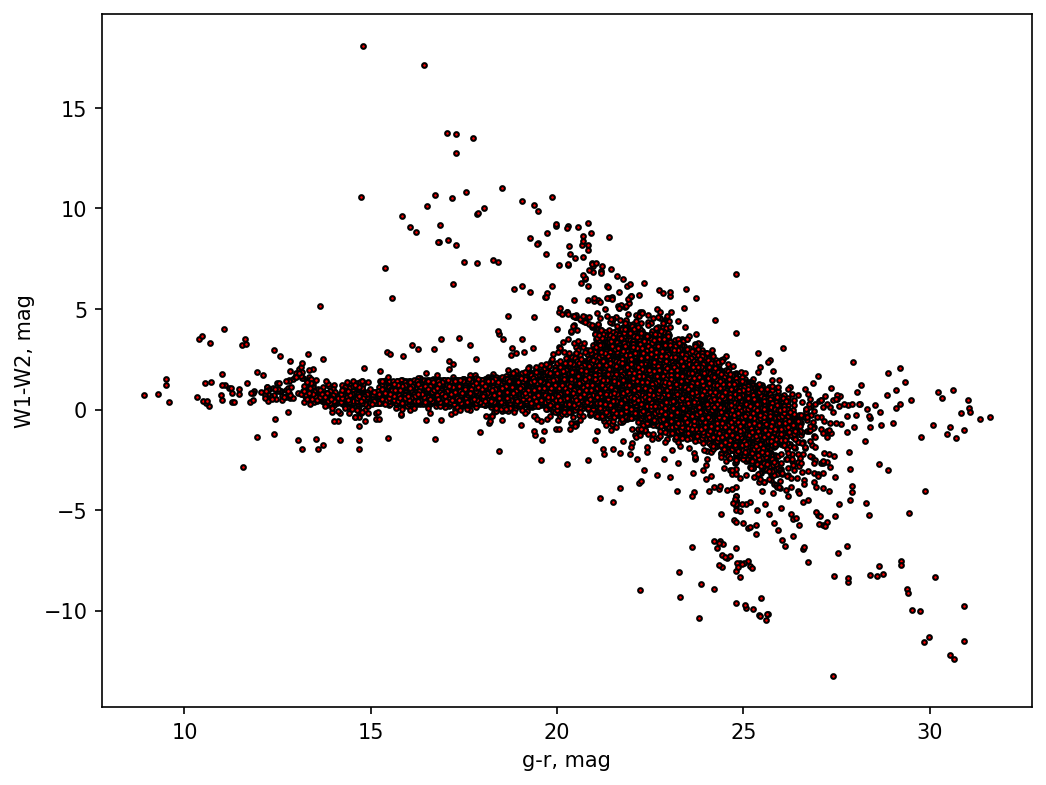

In [204]:
plot_color_color(proc_master_table)

In [205]:
target_sdss_objid = 1237665531726202157
target_desi_id = 8000409857001479

sdss_row = sdss[sdss["objID"] == target_sdss_objid]
desi_row = clean_desi_south[clean_desi_south["id"] == target_desi_id]

print("SDSS rows found:", len(sdss_row))
print("DESI rows found:", len(desi_row))

if len(sdss_row) and len(desi_row):
    c_sdss = SkyCoord(sdss_row["ra"][0] * u.deg, sdss_row["dec"][0] * u.deg)
    c_desi = SkyCoord(desi_row["ra"][0] * u.deg, desi_row["dec"][0] * u.deg)
    sep = c_sdss.separation(c_desi)
    print("Direct SDSS-DESI separation:", sep.to(u.arcsec))

    # nearest DESI to this SDSS source
    desi_coords = SkyCoord(clean_desi_south["ra"], clean_desi_south["dec"])
    i_desi, s_desi, _ = c_sdss.match_to_catalog_sky(desi_coords)
    print("Nearest DESI to SDSS obj:", clean_desi_south["id"][i_desi], "sep=", s_desi.to(u.arcsec))

    # nearest SDSS to this DESI source
    sdss_coords = SkyCoord(sdss["ra"], sdss["dec"])
    i_sdss, s_sdss, _ = c_desi.match_to_catalog_sky(sdss_coords)
    print("Nearest SDSS to DESI id:", sdss["objID"][i_sdss], "sep=", s_sdss.to(u.arcsec))

    mt_sdss = master_table[master_table["objID_SDSS-DR16"] == target_sdss_objid]
    mt_desi = master_table[master_table["id_DESI-DR8"] == target_desi_id]
    print("master_table rows with target SDSS objID:", len(mt_sdss))
    print("master_table rows with target DESI id:", len(mt_desi))

    if len(mt_sdss):
        cols = ["objID_SDSS-DR16", "ra_SDSS-DR16", "dec_SDSS-DR16", "id_DESI-DR8", "ra_DESI-DR8", "dec_DESI-DR8"]
        print("Row for target SDSS in master_table:")
        print(mt_sdss[cols])

    if len(mt_desi):
        cols = ["objID_SDSS-DR16", "ra_SDSS-DR16", "dec_SDSS-DR16", "id_DESI-DR8", "ra_DESI-DR8", "dec_DESI-DR8"]
        print("Row for target DESI in master_table:")
        print(mt_desi[cols])

SDSS rows found: 0
DESI rows found: 1


In [206]:
import numpy as np
from astropy.table import Table, MaskedColumn

def run_basic_tests():
    t = Table()
    n = 9

    t["ra_SDSS-DR16"] = np.array([10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0], dtype=float)
    t["dec_SDSS-DR16"] = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0], dtype=float)

    t["ra_CatWISE"] = np.array([10.2, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float)
    t["dec_CatWISE"] = np.array([1.2, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float)

    t["ra_GAIA-DR3"] = np.array([9.8, 20.2, 30.2, 40.2, np.nan, 60.2, 70.0, np.nan, np.nan], dtype=float)
    t["dec_GAIA-DR3"] = np.array([0.8, 2.2, 3.2, 4.2, np.nan, 6.2, 7.0, np.nan, np.nan], dtype=float)

    t["ra_DESI-DR8"] = np.array([np.nan, np.nan, np.nan, 40.1, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float)
    t["dec_DESI-DR8"] = np.array([np.nan, np.nan, np.nan, 4.1, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float)

    t["ra_GLADE+"] = np.array([np.nan, 20.4, 30.4, 40.4, 50.4, 60.0, np.nan, np.nan, np.nan], dtype=float)
    t["dec_GLADE+"] = np.array([np.nan, 2.4, 3.4, 4.4, 5.4, 6.0, np.nan, np.nan, np.nan], dtype=float)

    t["ra_NED-LVS"] = np.array([np.nan, np.nan, np.nan, np.nan, 50.2, np.nan, 70.2, 80.0, np.nan], dtype=float)
    t["dec_NED-LVS"] = np.array([np.nan, np.nan, np.nan, np.nan, 5.2, np.nan, 7.2, 8.0, np.nan], dtype=float)

    t["D_L_NED-LVS"] = np.array([150.0, np.nan, np.nan, np.nan, 90.0, np.nan, np.nan, 77.0, np.nan], dtype=float) * u.Mpc
    t["e_D_L_NED-LVS"] = np.array([10.0, np.nan, np.nan, np.nan, 10.0, np.nan, np.nan, 7.0, np.nan], dtype=float) * u.Mpc
    t["z_tech_NED-LVS"] = np.array(["SPEC", "", "", "", "PHOT", "", "UNKN", "UNKN", ""], dtype=object)

    t["D_L_SDSS-DR16"] = np.array([500.0, 500.0, 170.0, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float) * u.Mpc
    t["e_D_L_SDSS-DR16"] = np.array([0.0, 0.0, 5.0, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float) * u.Mpc
    # 3σ asymmetric bounds for SDSS phot (row 2): D_L=170, e=5 → low=155, high=185
    t["D_L_low_SDSS-DR16"]  = np.array([np.nan, np.nan, 155.0, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float) * u.Mpc
    t["D_L_high_SDSS-DR16"] = np.array([np.nan, np.nan, 185.0, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float) * u.Mpc

    t["D_L_DESI-DR8"] = np.array([np.nan, np.nan, np.nan, 200.0, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float) * u.Mpc
    t["e_D_L_DESI-DR8"] = np.array([np.nan, np.nan, np.nan, 8.0, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float) * u.Mpc
    # 3σ asymmetric bounds for DESI phot (row 3): D_L=200, e=8 → low=176, high=224
    t["D_L_low_DESI-DR8"]   = np.array([np.nan, np.nan, np.nan, 176.0, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float) * u.Mpc
    t["D_L_high_DESI-DR8"]  = np.array([np.nan, np.nan, np.nan, 224.0, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float) * u.Mpc

    t["D_L_GLADE+"] = np.array([250.0, 100.0, 100.0, np.nan, 160.0, 160.0, np.nan, np.nan, np.nan], dtype=float) * u.Mpc

    t["Dist_GAIA-DR3"] = np.array([30.0, 40.0, 40.0, 12.0, np.nan, 42.0, 12.0, np.nan, np.nan], dtype=float) * u.Mpc

    t["objtype_NED-LVS"] = np.array(["", "", "", "", "", "", "", "GALAXY", ""], dtype=object)
    t["class_SDSS-DR16"] = np.array([1.0, 7.0, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float)
    t["is_qso_CatWISE"] = np.array([False, False, True, False, False, False, False, False, False], dtype=bool)
    t["pstar_DESI-DR8"] = np.array([np.nan, np.nan, np.nan, 0.8, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float)
    t["high_PM_GAIA-DR3"] = np.array([False, False, False, False, False, False, True, False, False], dtype=bool)

    out = process_master_table(t)

    expected_ra = np.array([10.0, 20.2, 30.2, 40.175, 50.2, 60.06666666666666, 70.06666666666666, 80.0, 90.0], dtype=float)
    expected_dec = np.array([1.0, 2.2, 3.2, 4.175, 5.2, 6.06666666666666, 7.06666666666666, 8.0, 9.0], dtype=float)
    expected_class = np.array(["G", "S", "QSO", "S", "Unknown", "Unknown", "S", "GALAXY", "Unknown"], dtype=object)
    expected_source = np.array([
        "NED-LVS spec",
        "SDSS-DR16 spec",
        "SDSS-DR16 phot",
        "DESI-DR8 phot",
        "NED-LVS phot",
        "GLADE+",
        "GAIA-DR3",
        "NED-LVS unknown",
        "unknown",
    ], dtype=object)
    expected_dl = np.array([150.0, 500.0, 170.0, 200.0, 90.0, 160.0, 12.0, 77.0, np.nan], dtype=float)
    expected_edl = np.array([10.0, 0.0, 5.0, 8.0, 30.0, 0.0, 0.0, 7.0, np.nan], dtype=float)
    expected_beyond = np.array([False, True, False, False, False, False, True, True, False], dtype=bool)

    np.testing.assert_allclose(np.asarray(out["ra_fin"], dtype=float), expected_ra, rtol=0, atol=1e-12)
    np.testing.assert_allclose(np.asarray(out["dec_fin"], dtype=float), expected_dec, rtol=0, atol=1e-12)
    np.testing.assert_allclose(np.asarray(out["D_L_fin"], dtype=float), expected_dl, rtol=0, atol=1e-12, equal_nan=True)
    np.testing.assert_allclose(np.asarray(out["e_D_L_fin"], dtype=float), expected_edl, rtol=0, atol=1e-12, equal_nan=True)

    actual_class = np.array([str(x).strip() for x in out["class_fin"]], dtype=object)
    actual_source = np.array([str(x).strip() for x in out["z_src_fin"]], dtype=object)
    actual_beyond = np.asarray(out["beyond_dist_limit"], dtype=bool)

    assert np.array_equal(actual_class, expected_class), f"class_fin mismatch: {actual_class!r}"
    assert np.array_equal(actual_source, expected_source), f"z_src_fin mismatch: {actual_source!r}"
    assert np.array_equal(actual_beyond, expected_beyond), f"beyond_dist_limit mismatch: {actual_beyond!r}"
    assert int(np.count_nonzero(np.isfinite(np.asarray(out["D_L_fin"], dtype=float)))) == 8
    assert int(np.count_nonzero(np.asarray(out["class_fin"], dtype=object) == "Unknown")) == 3

    print("All synthetic algorithm tests passed.")
    print("Rows exercised: NED spec, SDSS spec, SDSS phot, DESI phot, NED phot, GLADE+, GAIA, NED unknown, no distance.")
    return out

def _masked_col(values, mask, unit=None, dtype=float):
    column = MaskedColumn(data=np.array(values, dtype=dtype), mask=np.array(mask, dtype=bool))
    if unit is not None:
        column.unit = unit
    return column

def run_masked_outer_join_tests():
    t = Table()

    t["ra_SDSS-DR16"] = _masked_col([10.0, 20.0, 0.0, 0.0], [False, False, True, True])
    t["dec_SDSS-DR16"] = _masked_col([1.0, 2.0, 0.0, 0.0], [False, False, True, True])

    t["ra_CatWISE"] = _masked_col([10.2, 20.0, 30.0, 0.0], [False, False, False, True])
    t["dec_CatWISE"] = _masked_col([1.2, 2.0, 3.0, 0.0], [False, False, False, True])

    t["ra_GAIA-DR3"] = _masked_col([0.0, 20.0, 0.0, 40.0], [True, False, True, False])
    t["dec_GAIA-DR3"] = _masked_col([0.0, 2.0, 0.0, 4.0], [True, False, True, False])

    t["ra_DESI-DR8"] = _masked_col([0.0, 0.0, 0.0, 0.0], [True, True, True, True])
    t["dec_DESI-DR8"] = _masked_col([0.0, 0.0, 0.0, 0.0], [True, True, True, True])

    t["ra_GLADE+"] = _masked_col([9.8, 20.0, 30.0, 0.0], [False, False, False, True])
    t["dec_GLADE+"] = _masked_col([0.8, 2.0, 3.0, 0.0], [False, False, False, True])

    t["ra_NED-LVS"] = _masked_col([10.0, 0.0, 0.0, 40.0], [False, True, True, False])
    t["dec_NED-LVS"] = _masked_col([1.0, 0.0, 0.0, 4.0], [False, True, True, False])

    t["D_L_NED-LVS"] = np.array([120.0, np.nan, np.nan, 77.0], dtype=float) * u.Mpc
    t["e_D_L_NED-LVS"] = np.array([5.0, np.nan, np.nan, 7.0], dtype=float) * u.Mpc
    t["z_tech_NED-LVS"] = np.array(["SPEC", "", "", "UNKN"], dtype=object)

    t["D_L_SDSS-DR16"] = np.array([np.nan, 170.0, np.nan, np.nan], dtype=float) * u.Mpc
    t["e_D_L_SDSS-DR16"] = np.array([np.nan, 5.0, np.nan, np.nan], dtype=float) * u.Mpc

    t["D_L_DESI-DR8"] = np.array([np.nan, np.nan, np.nan, np.nan], dtype=float) * u.Mpc
    t["e_D_L_DESI-DR8"] = np.array([np.nan, np.nan, np.nan, np.nan], dtype=float) * u.Mpc

    t["D_L_GLADE+"] = np.array([250.0, 100.0, 160.0, np.nan], dtype=float) * u.Mpc

    t["Dist_GAIA-DR3"] = np.array([np.nan, 40.0, np.nan, 12.0], dtype=float) * u.Mpc

    t["objtype_NED-LVS"] = np.array(["GALAXY", "", "", ""], dtype=object)
    t["class_SDSS-DR16"] = np.array([np.nan, 4.0, np.nan, np.nan], dtype=float)
    t["is_qso_CatWISE"] = np.array([False, True, True, False], dtype=bool)
    t["pstar_DESI-DR8"] = np.array([np.nan, np.nan, np.nan, np.nan], dtype=float)
    t["high_PM_GAIA-DR3"] = np.array([False, False, False, True], dtype=bool)

    out = process_master_table(t)

    expected_ra = np.array([10.0, 20.0, 30.0, 40.0], dtype=float)
    expected_dec = np.array([1.0, 2.0, 3.0, 4.0], dtype=float)
    expected_class = np.array(["GALAXY", "G", "QSO", "S"], dtype=object)
    expected_source = np.array(["NED-LVS spec", "SDSS-DR16 phot", "GLADE+", "GAIA-DR3"], dtype=object)
    expected_dl = np.array([120.0, 170.0, 160.0, 12.0], dtype=float)
    expected_edl = np.array([5.0, 15.0, 0.0, 0.0], dtype=float)
    expected_beyond = np.array([False, False, False, True], dtype=bool)

    np.testing.assert_allclose(np.asarray(out["ra_fin"], dtype=float), expected_ra, rtol=0, atol=1e-12)
    np.testing.assert_allclose(np.asarray(out["dec_fin"], dtype=float), expected_dec, rtol=0, atol=1e-12)
    np.testing.assert_allclose(np.asarray(out["D_L_fin"], dtype=float), expected_dl, rtol=0, atol=1e-12)
    np.testing.assert_allclose(np.asarray(out["e_D_L_fin"], dtype=float), expected_edl, rtol=0, atol=1e-12)

    actual_class = np.array([str(x).strip() for x in out["class_fin"]], dtype=object)
    actual_source = np.array([str(x).strip() for x in out["z_src_fin"]], dtype=object)
    actual_beyond = np.asarray(out["beyond_dist_limit"], dtype=bool)

    assert np.array_equal(actual_class, expected_class), f"masked class_fin mismatch: {actual_class!r}"
    assert np.array_equal(actual_source, expected_source), f"masked z_src_fin mismatch: {actual_source!r}"
    assert np.array_equal(actual_beyond, expected_beyond), f"masked beyond_dist_limit mismatch: {actual_beyond!r}"
    assert int(np.count_nonzero(np.asarray(out["class_fin"], dtype=object) == "Unknown")) == 0
    assert int(np.count_nonzero(np.isfinite(np.asarray(out["D_L_fin"], dtype=float)))) == 4

    print("All masked outer-join tests passed.")
    print("Rows exercised: masked SDSS/CatWISE/GAIA/outer-join coords, classification priority, and distance priority.")
    return out

test_out = run_basic_tests()
masked_test_out = run_masked_outer_join_tests()

All synthetic algorithm tests passed.
Rows exercised: NED spec, SDSS spec, SDSS phot, DESI phot, NED phot, GLADE+, GAIA, NED unknown, no distance.


KeyError: 'D_L_low_SDSS-DR16'

In [ ]:
def run_priority_conflict_regression_test():
    t = Table()

    t["ra_NED-LVS"] = np.array([42.0, np.nan, np.nan], dtype=float)
    t["dec_NED-LVS"] = np.array([13.0, np.nan, np.nan], dtype=float)
    t["ra_SDSS-DR16"] = np.array([42.0, 43.0, 44.0], dtype=float)
    t["dec_SDSS-DR16"] = np.array([13.0, 14.0, 15.0], dtype=float)
    t["ra_GAIA-DR3"] = np.array([42.0, 43.0, 44.0], dtype=float)
    t["dec_GAIA-DR3"] = np.array([13.0, 14.0, 15.0], dtype=float)
    t["ra_DESI-DR8"] = np.array([42.0, 43.0, 44.0], dtype=float)
    t["dec_DESI-DR8"] = np.array([13.0, 14.0, 15.0], dtype=float)

    t["D_L_NED-LVS"] = np.array([150.0, np.nan, np.nan], dtype=float) * u.Mpc
    t["e_D_L_NED-LVS"] = np.array([10.0, np.nan, np.nan], dtype=float) * u.Mpc
    t["z_tech_NED-LVS"] = np.array(["SPEC", "", ""], dtype=object)

    t["D_L_SDSS-DR16"] = np.array([999.0, 170.0, np.nan], dtype=float) * u.Mpc
    t["e_D_L_SDSS-DR16"] = np.array([2.0, 5.0, np.nan], dtype=float) * u.Mpc
    # 3σ bounds for SDSS phot (row 1): D_L=170, e=5 → [155, 185]
    t["D_L_low_SDSS-DR16"]  = np.array([np.nan, 155.0, np.nan], dtype=float) * u.Mpc
    t["D_L_high_SDSS-DR16"] = np.array([np.nan, 185.0, np.nan], dtype=float) * u.Mpc

    t["D_L_DESI-DR8"] = np.array([12.0, 200.0, 200.0], dtype=float) * u.Mpc
    t["e_D_L_DESI-DR8"] = np.array([1.0, 8.0, 8.0], dtype=float) * u.Mpc
    # 3σ bounds for DESI phot (rows 1, 2): D_L=200, e=8 → [176, 224]
    t["D_L_low_DESI-DR8"]   = np.array([np.nan, 176.0, 176.0], dtype=float) * u.Mpc
    t["D_L_high_DESI-DR8"]  = np.array([np.nan, 224.0, 224.0], dtype=float) * u.Mpc
    t["D_L_GLADE+"] = np.array([12.0, np.nan, np.nan], dtype=float) * u.Mpc
    t["Dist_GAIA-DR3"] = np.array([5.0, 5.0, 12.0], dtype=float) * u.Mpc

    t["objtype_NED-LVS"] = np.array(["GALAXY", "", ""], dtype=object)
    t["class_SDSS-DR16"] = np.array([7.0, 4.0, 4.0], dtype=float)
    t["is_qso_CatWISE"] = np.array([False, False, False], dtype=bool)
    t["pstar_DESI-DR8"] = np.array([0.9, 0.1, 0.9], dtype=float)
    t["high_PM_GAIA-DR3"] = np.array([True, False, True], dtype=bool)

    assert "D_L_SDSS-DR16" in t.colnames
    assert "D_L_DESI-DR8" in t.colnames

    out = process_master_table(t)

    expected_ra = np.array([42.0, 43.0, 44.0], dtype=float)
    expected_dec = np.array([13.0, 14.0, 15.0], dtype=float)
    expected_class = np.array(["S", "G", "S"], dtype=object)
    expected_source = np.array(["NED-LVS spec", "SDSS-DR16 phot", "DESI-DR8 phot"], dtype=object)
    expected_dl = np.array([150.0, 170.0, 200.0], dtype=float)
    expected_edl = np.array([10.0, 5.0, 8.0], dtype=float)
    expected_beyond = np.array([False, False, False], dtype=bool)

    np.testing.assert_allclose(np.asarray(out["ra_fin"], dtype=float), expected_ra, rtol=0, atol=1e-12)
    np.testing.assert_allclose(np.asarray(out["dec_fin"], dtype=float), expected_dec, rtol=0, atol=1e-12)
    np.testing.assert_allclose(np.asarray(out["D_L_fin"], dtype=float), expected_dl, rtol=0, atol=1e-12)
    np.testing.assert_allclose(np.asarray(out["e_D_L_fin"], dtype=float), expected_edl, rtol=0, atol=1e-12)

    actual_class = np.array([str(x).strip() for x in out["class_fin"]], dtype=object)
    actual_source = np.array([str(x).strip() for x in out["z_src_fin"]], dtype=object)
    actual_beyond = np.asarray(out["beyond_dist_limit"], dtype=bool)

    assert np.array_equal(actual_class, expected_class), f"class_fin mismatch: {actual_class!r}"
    assert np.array_equal(actual_source, expected_source), f"z_src_fin mismatch: {actual_source!r}"
    assert np.array_equal(actual_beyond, expected_beyond), f"beyond_dist_limit mismatch: {actual_beyond!r}"
    assert bool(out["high_PM_GAIA-DR3"][0]) is True
    assert bool(out["high_PM_GAIA-DR3"][1]) is False
    assert bool(out["high_PM_GAIA-DR3"][2]) is True

    print("Priority conflict regression test passed.")
    print("Conflict exercised: NED spec beats SDSS phot, SDSS phot beats DESI phot, and GAIA high_PM only affects class.")
    return out

priority_conflict_out = run_priority_conflict_regression_test()

Priority conflict regression test passed.
Conflict exercised: NED spec beats SDSS phot, SDSS phot beats DESI phot, and GAIA high_PM only affects class.


In [ ]:
def run_zero_distance_regression_test():
    t = Table()

    t["ra_SDSS-DR16"] = np.array([123.0], dtype=float)
    t["dec_SDSS-DR16"] = np.array([45.0], dtype=float)
    t["D_L_SDSS-DR16"] = np.array([np.nan], dtype=float) * u.Mpc
    t["e_D_L_SDSS-DR16"] = np.array([np.nan], dtype=float) * u.Mpc
    t["D_L_NED-LVS"] = np.array([np.nan], dtype=float) * u.Mpc
    t["e_D_L_NED-LVS"] = np.array([np.nan], dtype=float) * u.Mpc
    t["z_tech_NED-LVS"] = np.array([""], dtype=object)
    t["D_L_DESI-DR8"] = MaskedColumn(data=np.array([0.0], dtype=float), mask=np.array([True], dtype=bool)) * u.Mpc
    t["e_D_L_DESI-DR8"] = MaskedColumn(data=np.array([np.nan], dtype=float), mask=np.array([True], dtype=bool)) * u.Mpc
    t["D_L_low_DESI-DR8"]  = MaskedColumn(data=np.array([np.nan], dtype=float), mask=np.array([True], dtype=bool)) * u.Mpc
    t["D_L_high_DESI-DR8"] = MaskedColumn(data=np.array([np.nan], dtype=float), mask=np.array([True], dtype=bool)) * u.Mpc
    t["D_L_low_SDSS-DR16"]  = np.array([np.nan], dtype=float) * u.Mpc
    t["D_L_high_SDSS-DR16"] = np.array([np.nan], dtype=float) * u.Mpc
    t["D_L_GLADE+"] = np.array([np.nan], dtype=float) * u.Mpc
    t["Dist_GAIA-DR3"] = np.array([np.nan], dtype=float) * u.Mpc
    t["objtype_NED-LVS"] = np.array([""], dtype=object)
    t["class_SDSS-DR16"] = np.array([3.0], dtype=float)
    t["is_qso_CatWISE"] = np.array([False], dtype=bool)
    t["pstar_DESI-DR8"] = np.array([np.nan], dtype=float)
    t["high_PM_GAIA-DR3"] = np.array([False], dtype=bool)

    out = process_master_table(t)

    assert np.isnan(float(out["D_L_fin"][0]))
    assert np.isnan(float(out["e_D_L_fin"][0]))
    assert bool(out["beyond_dist_limit"][0]) is False
    assert str(out["class_fin"][0]).strip() == "G"
    assert str(out["z_src_fin"][0]).strip() == "unknown"

    galaxies = out[(out['class_fin'] == 'G') & (out['beyond_dist_limit'] == False)]
    assert len(galaxies) == 1

    print("Masked-DESI regression test passed.")
    return out

zero_distance_out = run_zero_distance_regression_test()

Masked-DESI regression test passed.


In [ ]:
import numpy as np
from astropy.table import Table, MaskedColumn


def run_basic_tests():
    t = Table()

    t["ra_SDSS-DR16"] = np.array([10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0], dtype=float)
    t["dec_SDSS-DR16"] = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0], dtype=float)

    t["ra_CatWISE"] = np.array([10.2, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float)
    t["dec_CatWISE"] = np.array([1.2, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float)

    t["ra_GAIA-DR3"] = np.array([9.8, 20.2, 30.2, 40.2, np.nan, 60.2, 70.0, np.nan, np.nan], dtype=float)
    t["dec_GAIA-DR3"] = np.array([0.8, 2.2, 3.2, 4.2, np.nan, 6.2, 7.0, np.nan, np.nan], dtype=float)

    t["ra_DESI-DR8"] = np.array([np.nan, np.nan, np.nan, 40.1, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float)
    t["dec_DESI-DR8"] = np.array([np.nan, np.nan, np.nan, 4.1, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float)

    t["ra_GLADE+"] = np.array([np.nan, 20.4, 30.4, 40.4, 50.4, 60.0, np.nan, np.nan, np.nan], dtype=float)
    t["dec_GLADE+"] = np.array([np.nan, 2.4, 3.4, 4.4, 5.4, 6.0, np.nan, np.nan, np.nan], dtype=float)

    t["ra_NED-LVS"] = np.array([np.nan, np.nan, np.nan, np.nan, 50.2, np.nan, 70.2, 80.0, np.nan], dtype=float)
    t["dec_NED-LVS"] = np.array([np.nan, np.nan, np.nan, np.nan, 5.2, np.nan, 7.2, 8.0, np.nan], dtype=float)

    t["D_L_NED-LVS"] = np.array([150.0, np.nan, np.nan, np.nan, 90.0, np.nan, np.nan, 77.0, np.nan], dtype=float) * u.Mpc
    t["e_D_L_NED-LVS"] = np.array([10.0, np.nan, np.nan, np.nan, 10.0, np.nan, np.nan, 7.0, np.nan], dtype=float) * u.Mpc
    t["z_tech_NED-LVS"] = np.array(["SPEC", "", "", "", "PHOT", "", "UNKN", "UNKN", ""], dtype=object)

    t["D_L_SDSS-DR16"] = np.array([500.0, 500.0, 170.0, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float) * u.Mpc
    t["e_D_L_SDSS-DR16"] = np.array([0.0, 0.0, 5.0, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float) * u.Mpc

    t["D_L_DESI-DR8"] = np.array([np.nan, np.nan, np.nan, 200.0, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float) * u.Mpc
    t["e_D_L_DESI-DR8"] = np.array([np.nan, np.nan, np.nan, 8.0, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float) * u.Mpc

    t["D_L_GLADE+"] = np.array([250.0, 100.0, 100.0, np.nan, 160.0, 160.0, np.nan, np.nan, np.nan], dtype=float) * u.Mpc

    t["Dist_GAIA-DR3"] = np.array([30.0, 40.0, 40.0, 12.0, np.nan, 42.0, 12.0, np.nan, np.nan], dtype=float) * u.Mpc

    t["objtype_NED-LVS"] = np.array(["", "", "", "", "", "", "", "GALAXY", ""], dtype=object)
    t["class_SDSS-DR16"] = np.array([1.0, 7.0, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float)
    t["is_qso_CatWISE"] = np.array([False, False, True, False, False, False, False, False, False], dtype=bool)
    t["pstar_DESI-DR8"] = np.array([np.nan, np.nan, np.nan, 0.8, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float)
    t["high_PM_GAIA-DR3"] = np.array([False, False, False, False, False, False, True, False, False], dtype=bool)

    out = process_master_table(t)

    expected_rows = [
        ("NED spec", 10.0, 1.0, 150.0, 10.0, "G", "NED-LVS spec", False),
        ("SDSS spec", 20.2, 2.2, 500.0, 0.0, "S", "SDSS-DR16 spec", True),
        ("SDSS phot + CatWISE QSO", 30.2, 3.2, 170.0, 15.0, "QSO", "SDSS-DR16 phot", False),
        ("DESI phot", 40.175, 4.175, 200.0, 24.0, "S", "DESI-DR8 phot", False),
        ("NED phot", 50.2, 5.2, 90.0, 30.0, "Unknown", "NED-LVS phot", False),
        ("GLADE+ fallback", 60.06666666666666, 6.06666666666666, 160.0, 0.0, "Unknown", "GLADE+", False),
        ("GAIA-DR3 + high_PM", 70.06666666666666, 7.06666666666666, 12.0, 0.0, "S", "GAIA-DR3", True),
        ("NED unknown", 80.0, 8.0, 77.0, 7.0, "GALAXY", "NED-LVS unknown", True),
        ("no distance", 90.0, 9.0, np.nan, np.nan, "Unknown", "unknown", False),
    ]

    expected_ra = np.array([row[1] for row in expected_rows], dtype=float)
    expected_dec = np.array([row[2] for row in expected_rows], dtype=float)
    expected_dl = np.array([row[3] for row in expected_rows], dtype=float)
    expected_edl = np.array([row[4] for row in expected_rows], dtype=float)
    expected_class = np.array([row[5] for row in expected_rows], dtype=object)
    expected_source = np.array([row[6] for row in expected_rows], dtype=object)
    expected_beyond = np.array([row[7] for row in expected_rows], dtype=bool)

    np.testing.assert_allclose(np.asarray(out["ra_fin"], dtype=float), expected_ra, rtol=0, atol=1e-12)
    np.testing.assert_allclose(np.asarray(out["dec_fin"], dtype=float), expected_dec, rtol=0, atol=1e-12)
    np.testing.assert_allclose(np.asarray(out["D_L_fin"], dtype=float), expected_dl, rtol=0, atol=1e-12, equal_nan=True)
    np.testing.assert_allclose(np.asarray(out["e_D_L_fin"], dtype=float), expected_edl, rtol=0, atol=1e-12, equal_nan=True)

    actual_class = np.array([str(x).strip() for x in out["class_fin"]], dtype=object)
    actual_source = np.array([str(x).strip() for x in out["z_src_fin"]], dtype=object)
    actual_beyond = np.asarray(out["beyond_dist_limit"], dtype=bool)

    assert np.array_equal(actual_class, expected_class), f"class_fin mismatch: {actual_class!r}"
    assert np.array_equal(actual_source, expected_source), f"z_src_fin mismatch: {actual_source!r}"
    assert np.array_equal(actual_beyond, expected_beyond), f"beyond_dist_limit mismatch: {actual_beyond!r}"
    assert int(np.count_nonzero(np.isfinite(np.asarray(out["D_L_fin"], dtype=float)))) == 8
    assert int(np.count_nonzero(np.asarray(out["class_fin"], dtype=object) == "Unknown")) == 3

    print("All synthetic algorithm tests passed.")
    print("Rows exercised: NED spec, SDSS spec, SDSS phot + CatWISE QSO, DESI phot, NED phot, GLADE+, GAIA + high_PM, NED unknown, no distance.")
    return out


def _masked_col(values, mask, unit=None, dtype=float):
    column = MaskedColumn(data=np.array(values, dtype=dtype), mask=np.array(mask, dtype=bool))
    if unit is not None:
        column.unit = unit
    return column


def run_masked_outer_join_tests():
    t = Table()

    t["ra_SDSS-DR16"] = _masked_col([10.0, 20.0, 0.0, 0.0], [False, False, True, True])
    t["dec_SDSS-DR16"] = _masked_col([1.0, 2.0, 0.0, 0.0], [False, False, True, True])

    t["ra_CatWISE"] = _masked_col([10.2, 20.0, 30.0, 0.0], [False, False, False, True])
    t["dec_CatWISE"] = _masked_col([1.2, 2.0, 3.0, 0.0], [False, False, False, True])

    t["ra_GAIA-DR3"] = _masked_col([0.0, 20.0, 0.0, 40.0], [True, False, True, False])
    t["dec_GAIA-DR3"] = _masked_col([0.0, 2.0, 0.0, 4.0], [True, False, True, False])

    t["ra_DESI-DR8"] = _masked_col([0.0, 0.0, 0.0, 0.0], [True, True, True, True])
    t["dec_DESI-DR8"] = _masked_col([0.0, 0.0, 0.0, 0.0], [True, True, True, True])

    t["ra_GLADE+"] = _masked_col([9.8, 20.0, 30.0, 0.0], [False, False, False, True])
    t["dec_GLADE+"] = _masked_col([0.8, 2.0, 3.0, 0.0], [False, False, False, True])

    t["ra_NED-LVS"] = _masked_col([10.0, 0.0, 0.0, 40.0], [False, True, True, False])
    t["dec_NED-LVS"] = _masked_col([1.0, 0.0, 0.0, 4.0], [False, True, True, False])

    t["D_L_NED-LVS"] = np.array([120.0, np.nan, np.nan, 77.0], dtype=float) * u.Mpc
    t["e_D_L_NED-LVS"] = np.array([5.0, np.nan, np.nan, 7.0], dtype=float) * u.Mpc
    t["z_tech_NED-LVS"] = np.array(["SPEC", "", "", "UNKN"], dtype=object)

    t["D_L_SDSS-DR16"] = np.array([np.nan, 170.0, np.nan, np.nan], dtype=float) * u.Mpc
    t["e_D_L_SDSS-DR16"] = np.array([np.nan, 5.0, np.nan, np.nan], dtype=float) * u.Mpc
    # 3σ bounds for SDSS phot (row 1): D_L=170, e=5 → [155, 185]
    t["D_L_low_SDSS-DR16"]  = np.array([np.nan, 155.0, np.nan, np.nan], dtype=float) * u.Mpc
    t["D_L_high_SDSS-DR16"] = np.array([np.nan, 185.0, np.nan, np.nan], dtype=float) * u.Mpc

    t["D_L_DESI-DR8"] = np.array([np.nan, np.nan, np.nan, np.nan], dtype=float) * u.Mpc
    t["e_D_L_DESI-DR8"] = np.array([np.nan, np.nan, np.nan, np.nan], dtype=float) * u.Mpc
    t["D_L_low_DESI-DR8"]   = np.array([np.nan, np.nan, np.nan, np.nan], dtype=float) * u.Mpc
    t["D_L_high_DESI-DR8"]  = np.array([np.nan, np.nan, np.nan, np.nan], dtype=float) * u.Mpc

    t["D_L_GLADE+"] = np.array([250.0, 100.0, 160.0, np.nan], dtype=float) * u.Mpc

    t["Dist_GAIA-DR3"] = np.array([np.nan, 40.0, np.nan, 12.0], dtype=float) * u.Mpc

    t["objtype_NED-LVS"] = np.array(["GALAXY", "", "", ""], dtype=object)
    t["class_SDSS-DR16"] = np.array([np.nan, 4.0, np.nan, np.nan], dtype=float)
    t["is_qso_CatWISE"] = np.array([False, True, True, False], dtype=bool)
    t["pstar_DESI-DR8"] = np.array([np.nan, np.nan, np.nan, np.nan], dtype=float)
    t["high_PM_GAIA-DR3"] = np.array([False, False, False, True], dtype=bool)

    out = process_master_table(t)

    expected_rows = [
        ("NED spec", 10.0, 1.0, 120.0, 5.0, "GALAXY", "NED-LVS spec", False),
        ("SDSS phot", 20.0, 2.0, 170.0, 5.0, "G", "SDSS-DR16 phot", False),
        ("CatWISE QSO + GLADE+", 30.0, 3.0, 160.0, 0.0, "QSO", "GLADE+", False),
        ("GAIA-DR3 + high_PM", 40.0, 4.0, 12.0, 0.0, "S", "GAIA-DR3", True),
    ]

    expected_ra = np.array([row[1] for row in expected_rows], dtype=float)
    expected_dec = np.array([row[2] for row in expected_rows], dtype=float)
    expected_dl = np.array([row[3] for row in expected_rows], dtype=float)
    expected_edl = np.array([row[4] for row in expected_rows], dtype=float)
    expected_class = np.array([row[5] for row in expected_rows], dtype=object)
    expected_source = np.array([row[6] for row in expected_rows], dtype=object)
    expected_beyond = np.array([row[7] for row in expected_rows], dtype=bool)

    np.testing.assert_allclose(np.asarray(out["ra_fin"], dtype=float), expected_ra, rtol=0, atol=1e-12)
    np.testing.assert_allclose(np.asarray(out["dec_fin"], dtype=float), expected_dec, rtol=0, atol=1e-12)
    np.testing.assert_allclose(np.asarray(out["D_L_fin"], dtype=float), expected_dl, rtol=0, atol=1e-12)
    np.testing.assert_allclose(np.asarray(out["e_D_L_fin"], dtype=float), expected_edl, rtol=0, atol=1e-12)

    actual_class = np.array([str(x).strip() for x in out["class_fin"]], dtype=object)
    actual_source = np.array([str(x).strip() for x in out["z_src_fin"]], dtype=object)
    actual_beyond = np.asarray(out["beyond_dist_limit"], dtype=bool)

    assert np.array_equal(actual_class, expected_class), f"masked class_fin mismatch: {actual_class!r}"
    assert np.array_equal(actual_source, expected_source), f"masked z_src_fin mismatch: {actual_source!r}"
    assert np.array_equal(actual_beyond, expected_beyond), f"masked beyond_dist_limit mismatch: {actual_beyond!r}"
    assert int(np.count_nonzero(np.asarray(out["class_fin"], dtype=object) == "Unknown")) == 0
    assert int(np.count_nonzero(np.isfinite(np.asarray(out["D_L_fin"], dtype=float)))) == 4

    print("All masked outer-join tests passed.")
    print("Rows exercised: NED spec, SDSS phot, CatWISE QSO + GLADE+, GAIA + high_PM.")
    return out


test_out = run_basic_tests()
masked_test_out = run_masked_outer_join_tests()

All synthetic algorithm tests passed.
Rows exercised: NED spec, SDSS spec, SDSS phot + CatWISE QSO, DESI phot, NED phot, GLADE+, GAIA + high_PM, NED unknown, no distance.
All masked outer-join tests passed.
Rows exercised: NED spec, SDSS phot, CatWISE QSO + GLADE+, GAIA + high_PM.


In [ ]:
def inspect_current_process_master_table():
    t = Table()

    t["ra_SDSS-DR16"] = np.array([10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0], dtype=float)
    t["dec_SDSS-DR16"] = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0], dtype=float)
    t["ra_CatWISE"] = np.array([10.2, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float)
    t["dec_CatWISE"] = np.array([1.2, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float)
    t["ra_GAIA-DR3"] = np.array([9.8, 20.2, 30.2, 40.2, np.nan, 60.2, 70.0, np.nan, np.nan], dtype=float)
    t["dec_GAIA-DR3"] = np.array([0.8, 2.2, 3.2, 4.2, np.nan, 6.2, 7.0, np.nan, np.nan], dtype=float)
    t["ra_DESI-DR8"] = np.array([np.nan, np.nan, np.nan, 40.1, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float)
    t["dec_DESI-DR8"] = np.array([np.nan, np.nan, np.nan, 4.1, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float)
    t["ra_GLADE+"] = np.array([np.nan, 20.4, 30.4, 40.4, 50.4, 60.0, np.nan, np.nan, np.nan], dtype=float)
    t["dec_GLADE+"] = np.array([np.nan, 2.4, 3.4, 4.4, 5.4, 6.0, np.nan, np.nan, np.nan], dtype=float)
    t["ra_NED-LVS"] = np.array([np.nan, np.nan, np.nan, np.nan, 50.2, np.nan, 70.2, 80.0, np.nan], dtype=float)
    t["dec_NED-LVS"] = np.array([np.nan, np.nan, np.nan, np.nan, 5.2, np.nan, 7.2, 8.0, np.nan], dtype=float)

    t["D_L_NED-LVS"] = np.array([150.0, np.nan, np.nan, np.nan, 90.0, np.nan, np.nan, 77.0, np.nan], dtype=float) * u.Mpc
    t["e_D_L_NED-LVS"] = np.array([10.0, np.nan, np.nan, np.nan, 10.0, np.nan, np.nan, 7.0, np.nan], dtype=float) * u.Mpc
    t["z_tech_NED-LVS"] = np.array(["SPEC", "", "", "", "PHOT", "", "UNKN", "UNKN", ""], dtype=object)
    t["D_L_SDSS-DR16"] = np.array([500.0, 500.0, 170.0, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float) * u.Mpc
    t["e_D_L_SDSS-DR16"] = np.array([0.0, 0.0, 5.0, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float) * u.Mpc
    t["D_L_low_SDSS-DR16"]  = np.array([np.nan, np.nan, 155.0, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float) * u.Mpc
    t["D_L_high_SDSS-DR16"] = np.array([np.nan, np.nan, 185.0, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float) * u.Mpc
    t["D_L_DESI-DR8"] = np.array([np.nan, np.nan, np.nan, 200.0, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float) * u.Mpc
    t["e_D_L_DESI-DR8"] = np.array([np.nan, np.nan, np.nan, 8.0, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float) * u.Mpc
    t["D_L_low_DESI-DR8"]   = np.array([np.nan, np.nan, np.nan, 176.0, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float) * u.Mpc
    t["D_L_high_DESI-DR8"]  = np.array([np.nan, np.nan, np.nan, 224.0, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float) * u.Mpc
    t["D_L_GLADE+"] = np.array([250.0, 100.0, 100.0, np.nan, 160.0, 160.0, np.nan, np.nan, np.nan], dtype=float) * u.Mpc
    t["Dist_GAIA-DR3"] = np.array([30.0, 40.0, 40.0, 12.0, np.nan, 42.0, 12.0, np.nan, np.nan], dtype=float) * u.Mpc
    t["objtype_NED-LVS"] = np.array(["", "", "", "", "", "", "", "GALAXY", ""], dtype=object)
    t["class_SDSS-DR16"] = np.array([1.0, 7.0, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float)
    t["is_qso_CatWISE"] = np.array([False, False, True, False, False, False, False, False, False], dtype=bool)
    t["pstar_DESI-DR8"] = np.array([np.nan, np.nan, np.nan, 0.8, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float)
    t["high_PM_GAIA-DR3"] = np.array([False, False, False, False, False, False, True, False, False], dtype=bool)

    out = process_master_table(t)

    expected = {
        "ra_fin": np.array([10.0, 20.2, 30.2, 40.175, 50.2, 60.06666666666666, 70.06666666666666, 80.0, 90.0], dtype=float),
        "dec_fin": np.array([1.0, 2.2, 3.2, 4.175, 5.2, 6.06666666666666, 7.06666666666666, 8.0, 9.0], dtype=float),
        "D_L_fin": np.array([150.0, 500.0, 170.0, 200.0, 90.0, 160.0, 12.0, 77.0, np.nan], dtype=float),
        "e_D_L_fin": np.array([10.0, 0.0, 5.0, 8.0, 30.0, 0.0, 0.0, 7.0, np.nan], dtype=float),
        "class_fin": np.array(["G", "S", "QSO", "S", "Unknown", "Unknown", "S", "GALAXY", "Unknown"], dtype=object),
        "z_src_fin": np.array(["NED-LVS spec", "SDSS-DR16 spec", "SDSS-DR16 phot", "DESI-DR8 phot", "NED-LVS phot", "GLADE+", "GAIA-DR3", "NED-LVS unknown", "unknown"], dtype=object),
        "beyond_dist_limit": np.array([False, True, False, False, False, False, True, True, False], dtype=bool),
    }

    actual = {
        "ra_fin": np.asarray(out["ra_fin"], dtype=float),
        "dec_fin": np.asarray(out["dec_fin"], dtype=float),
        "D_L_fin": np.asarray(out["D_L_fin"], dtype=float),
        "e_D_L_fin": np.asarray(out["e_D_L_fin"], dtype=float),
        "class_fin": np.array([str(x).strip() for x in out["class_fin"]], dtype=object),
        "z_src_fin": np.array([str(x).strip() for x in out["z_src_fin"]], dtype=object),
        "beyond_dist_limit": np.asarray(out["beyond_dist_limit"], dtype=bool),
    }

    for key in expected:
        print(f"{key}:")
        print("  actual  =", actual[key])
        print("  expected=", expected[key])
        if actual[key].dtype.kind in "f":
            diff = actual[key] - expected[key]
            print("  diff    =", diff)
        else:
            print("  equal   =", np.array_equal(actual[key], expected[key]))
        print()

inspect_current_process_master_table()

ra_fin:


  actual  = [10.         20.2        30.2        40.175      50.2        60.06666667
 70.06666667 80.         90.        ]
  expected= [10.         20.2        30.2        40.175      50.2        60.06666667
 70.06666667 80.         90.        ]
  diff    = [0.00000000e+00 0.00000000e+00 0.00000000e+00 7.10542736e-15
 7.10542736e-15 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00]

dec_fin:
  actual  = [1.         2.2        3.2        4.175      5.2        6.06666667
 7.06666667 8.         9.        ]
  expected= [1.         2.2        3.2        4.175      5.2        6.06666667
 7.06666667 8.         9.        ]
  diff    = [ 0.00000000e+00 -4.44089210e-16 -4.44089210e-16  0.00000000e+00
  0.00000000e+00  6.21724894e-15  6.21724894e-15  0.00000000e+00
  0.00000000e+00]

D_L_fin:
  actual  = [150. 500. 170. 200.  90. 160.  12.  77.  nan]
  expected= [150. 500. 170. 200.  90. 160.  12.  77.  nan]
  diff    = [ 0.  0.  0.  0.  0.  0.  0.  0. nan]

e_D_L_fin:
  actual  = [1